In [1]:
# Cell 1 — Final precursor-risk model setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Project paths
PROJECT_ROOT = Path("..").resolve()
REPORTS_DIR = PROJECT_ROOT / "reports"

# Existing validated multi-infant event results
VALIDATION_FILE = REPORTS_DIR / "pics_multi_infant_validation_results.csv"

# Existing 03b development dataset
DEVELOPMENT_FILE = (
    REPORTS_DIR / "pics_multi_infant_precursor_development_features.csv"
)

# PICS infants
INFANTS = list(range(1, 11))

print("=" * 70)
print("FINAL PRECURSOR-RISK MODEL")
print("=" * 70)

print()
print("Project root:", PROJECT_ROOT)
print("Reports directory:", REPORTS_DIR)

print()
print("Validation file:")
print(VALIDATION_FILE)

print()
print("Development file:")
print(DEVELOPMENT_FILE)

print()
print("Infants:", INFANTS)

print()
print("=" * 70)
print("SETUP COMPLETE")
print("=" * 70)

FINAL PRECURSOR-RISK MODEL

Project root: C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor
Reports directory: C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports

Validation file:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_multi_infant_validation_results.csv

Development file:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_multi_infant_precursor_development_features.csv

Infants: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

SETUP COMPLETE


In [2]:
# Cell 2 — Load validated multi-infant event results

if not VALIDATION_FILE.exists():
    raise FileNotFoundError(
        f"Validation file not found:\n{VALIDATION_FILE}"
    )

validation_events_df = pd.read_csv(
    VALIDATION_FILE
)

print("=" * 70)
print("VALIDATED MULTI-INFANT EVENT DATASET")
print("=" * 70)

print()
print("Shape:", validation_events_df.shape)

print()
print("Columns:")
for i, column in enumerate(
    validation_events_df.columns,
    start=1
):
    print(f"{i:2d}: {column}")

print()
print("=" * 70)
print("INFANT DISTRIBUTION")
print("=" * 70)

print(
    validation_events_df["infant"]
    .value_counts()
    .sort_index()
)

print()
print("=" * 70)
print("EVENT DATA")
print("=" * 70)

display(
    validation_events_df.head(20)
)

print()
print("=" * 70)
print("EVENT DATASET LOADED")
print("=" * 70)

VALIDATED MULTI-INFANT EVENT DATASET

Shape: (20, 15)

Columns:
 1: infant
 2: event_number
 3: event_time_s
 4: ecg_fs
 5: resp_fs
 6: r_peak_count
 7: rr_count
 8: bradycardia_run_count
 9: resp_suppression_run_count
10: short_resp_with_brady_count
11: bradycardia_only_count
12: apnea_candidate_count
13: respiratory_suppression_count
14: classified_period_count
15: status

INFANT DISTRIBUTION
infant
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     2
9     2
10    2
Name: count, dtype: int64

EVENT DATA


,infant,event_number,event_time_s,ecg_fs,resp_fs,r_peak_count,rr_count,bradycardia_run_count,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,respiratory_suppression_count,classified_period_count,status
0,1,1,1971.372,250.0,500.0,147,146,1,0,0,1,0,0,1,success
1,1,2,3456.512,250.0,500.0,129,128,2,1,1,1,0,0,2,success
2,2,1,2235.784,500.0,50.0,114,113,1,0,0,1,0,0,1,success
3,2,2,4210.760,500.0,50.0,113,112,2,0,0,2,0,0,2,success
4,3,2,8143.846,500.0,50.0,113,112,3,1,1,2,0,0,3,success
5,3,3,9427.300,500.0,50.0,111,110,5,1,0,5,0,1,6,success
6,4,1,4790.382,500.0,50.0,150,149,1,0,0,1,0,0,1,success
7,4,2,10966.268,500.0,50.0,165,164,1,0,0,1,0,0,1,success
8,5,1,3650.344,250.0,50.0,129,128,2,0,0,2,0,0,2,success
9,5,2,5923.680,250.0,50.0,132,131,0,0,0,0,0,0,0,success



EVENT DATASET LOADED


In [3]:
# Cell 3 — Select the validated respiratory-suppression events

# These are the three respiratory-suppression candidates
# previously identified and visually validated in Notebook 03b.

POSITIVE_EVENTS = pd.DataFrame({
    "infant": [3, 9, 9],
    "event_number": [3, 1, 2],
    "event_time_s": [9427.300, 6900.050, 10072.600]
})

print("=" * 70)
print("VALIDATED POSITIVE EVENT CANDIDATES")
print("=" * 70)

display(POSITIVE_EVENTS)

print()
print("Number of positive events:", len(POSITIVE_EVENTS))

print()
print("=" * 70)
print("VERIFYING AGAINST MULTI-INFANT EVENT RESULTS")
print("=" * 70)

verification = validation_events_df.merge(
    POSITIVE_EVENTS,
    on=["infant", "event_number", "event_time_s"],
    how="inner"
)

display(
    verification[
        [
            "infant",
            "event_number",
            "event_time_s",
            "resp_suppression_run_count",
            "short_resp_with_brady_count",
            "bradycardia_only_count",
            "apnea_candidate_count",
            "respiratory_suppression_count",
            "classified_period_count",
            "status"
        ]
    ]
)

print()
print("Verified events:", len(verification))

if len(verification) != len(POSITIVE_EVENTS):
    raise ValueError(
        "Not all three positive events were found in the validated event dataset."
    )

print()
print("=" * 70)
print("CELL 3 COMPLETE — 3 EVENTS VERIFIED")
print("=" * 70)

VALIDATED POSITIVE EVENT CANDIDATES


,infant,event_number,event_time_s
0,3,3,9427.30
1,9,1,6900.05
2,9,2,10072.60



Number of positive events: 3

VERIFYING AGAINST MULTI-INFANT EVENT RESULTS


,infant,event_number,event_time_s,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,respiratory_suppression_count,classified_period_count,status
0,3,3,9427.30,1,0,5,0,1,6,success
1,9,1,6900.05,1,0,0,0,1,1,success
2,9,2,10072.60,1,0,0,0,1,1,success



Verified events: 3

CELL 3 COMPLETE — 3 EVENTS VERIFIED


In [4]:
# Cell 4 — Define 15-second precursor windows

PRECURSOR_WINDOW_SECONDS = 15.0

positive_precursor_windows = POSITIVE_EVENTS.copy()

positive_precursor_windows["precursor_start_s"] = (
    positive_precursor_windows["event_time_s"]
    - PRECURSOR_WINDOW_SECONDS
)

positive_precursor_windows["precursor_end_s"] = (
    positive_precursor_windows["event_time_s"]
)

positive_precursor_windows["window_duration_s"] = (
    positive_precursor_windows["precursor_end_s"]
    - positive_precursor_windows["precursor_start_s"]
)

print("=" * 70)
print("15-SECOND PRECURSOR WINDOWS")
print("=" * 70)

display(positive_precursor_windows)

print()
print("Number of precursor windows:",
      len(positive_precursor_windows))

print()
print("Window durations:")
print(
    positive_precursor_windows["window_duration_s"]
    .value_counts()
    .sort_index()
)

# Verify every window is exactly 15 seconds
if not np.allclose(
    positive_precursor_windows["window_duration_s"],
    PRECURSOR_WINDOW_SECONDS
):
    raise ValueError(
        "One or more precursor windows is not exactly 15 seconds."
    )

# Verify no window starts before recording time
if (positive_precursor_windows["precursor_start_s"] < 0).any():
    raise ValueError(
        "A precursor window starts before the beginning of a recording."
    )

print()
print("=" * 70)
print("CELL 4 COMPLETE — ALL WINDOWS ARE 15 SECONDS")
print("=" * 70)

15-SECOND PRECURSOR WINDOWS


,infant,event_number,event_time_s,precursor_start_s,precursor_end_s,window_duration_s
0,3,3,9427.30,9412.30,9427.30,15.0
1,9,1,6900.05,6885.05,6900.05,15.0
2,9,2,10072.60,10057.60,10072.60,15.0



Number of precursor windows: 3

Window durations:
window_duration_s
15.0    3
Name: count, dtype: int64

CELL 4 COMPLETE — ALL WINDOWS ARE 15 SECONDS


In [5]:
# Cell 5 — Define final feature-extraction parameters

FEATURE_WINDOW_SECONDS = 5.0
FEATURE_STEP_SECONDS = 1.0

# ECG features
ECG_FEATURES = [
    "ecg_mean",
    "ecg_std",
    "ecg_rms",
    "r_peak_count",
    "mean_rr",
    "std_rr",
    "mean_hr",
    "min_hr",
    "max_hr",
    "std_hr",
    "sdnn",
    "rmssd"
]

# Respiration features
RESP_FEATURES = [
    "resp_mean",
    "resp_std",
    "resp_rms",
    "resp_peak_count",
    "mean_resp_interval",
    "std_resp_interval",
    "mean_resp_rate",
    "std_resp_rate"
]

ALL_PHYSIO_FEATURES = ECG_FEATURES + RESP_FEATURES

print("=" * 70)
print("FINAL FEATURE EXTRACTION PARAMETERS")
print("=" * 70)

print()
print("Precursor window:", PRECURSOR_WINDOW_SECONDS, "seconds")
print("Feature window:", FEATURE_WINDOW_SECONDS, "seconds")
print("Feature step:", FEATURE_STEP_SECONDS, "seconds")

print()
print("ECG features:", len(ECG_FEATURES))
for feature in ECG_FEATURES:
    print("  -", feature)

print()
print("Respiration features:", len(RESP_FEATURES))
for feature in RESP_FEATURES:
    print("  -", feature)

print()
print("Total physiological features:", len(ALL_PHYSIO_FEATURES))

print()
print("=" * 70)
print("CELL 5 COMPLETE")
print("=" * 70)

FINAL FEATURE EXTRACTION PARAMETERS

Precursor window: 15.0 seconds
Feature window: 5.0 seconds
Feature step: 1.0 seconds

ECG features: 12
  - ecg_mean
  - ecg_std
  - ecg_rms
  - r_peak_count
  - mean_rr
  - std_rr
  - mean_hr
  - min_hr
  - max_hr
  - std_hr
  - sdnn
  - rmssd

Respiration features: 8
  - resp_mean
  - resp_std
  - resp_rms
  - resp_peak_count
  - mean_resp_interval
  - std_resp_interval
  - mean_resp_rate
  - std_resp_rate

Total physiological features: 20

CELL 5 COMPLETE


In [9]:
# Cell 6 — Load only the required PICS signal windows

import wfdb

PICS_PATH = "picsdb/1.0.0/"

# Padding is added around each 15-second precursor window
# to reduce edge effects during later signal processing.
SIGNAL_PADDING_SECONDS = 5.0

signal_windows = {}

print("=" * 70)
print("LOADING REQUIRED SIGNAL WINDOWS ONLY")
print("=" * 70)

for _, row in positive_precursor_windows.iterrows():

    infant = int(row["infant"])
    event_number = int(row["event_number"])

    window_start = float(row["precursor_start_s"])
    window_end = float(row["precursor_end_s"])

    load_start = max(
        0.0,
        window_start - SIGNAL_PADDING_SECONDS
    )

    load_end = (
        window_end + SIGNAL_PADDING_SECONDS
    )

    print()
    print(
        f"Infant {infant} | "
        f"Event {event_number}"
    )

    print(
        f"  Required precursor : "
        f"{window_start:.3f} – {window_end:.3f} s"
    )

    print(
        f"  Loading with padding: "
        f"{load_start:.3f} – {load_end:.3f} s"
    )

    # Load ECG segment
    ecg_record = wfdb.rdrecord(
        f"infant{infant}_ecg",
        sampfrom=int(
            load_start * 500
        ),
        sampto=int(
            load_end * 500
        ),
        pn_dir=PICS_PATH
    )

    # Load respiration segment
    resp_record = wfdb.rdrecord(
        f"infant{infant}_resp",
        sampfrom=int(
            load_start * 50
        ),
        sampto=int(
            load_end * 50
        ),
        pn_dir=PICS_PATH
    )

    signal_windows[
        (infant, event_number)
    ] = {
        "ecg": ecg_record.p_signal[:, 0],
        "resp": resp_record.p_signal[:, 0],
        "ecg_fs": float(ecg_record.fs),
        "resp_fs": float(resp_record.fs),
        "load_start_s": load_start,
        "load_end_s": load_end,
        "precursor_start_s": window_start,
        "precursor_end_s": window_end
    }

    print(
        f"  ECG samples : "
        f"{len(ecg_record.p_signal):,}"
    )

    print(
        f"  RESP samples: "
        f"{len(resp_record.p_signal):,}"
    )

print()
print("=" * 70)
print("SIGNAL WINDOWS LOADED")
print("=" * 70)

print()
print("Number of loaded windows:", len(signal_windows))

print()
for key, data in signal_windows.items():
    print(
        f"Infant {key[0]} Event {key[1]}: "
        f"ECG {data['ecg_fs']:.1f} Hz | "
        f"RESP {data['resp_fs']:.1f} Hz"
    )

LOADING REQUIRED SIGNAL WINDOWS ONLY

Infant 3 | Event 3
  Required precursor : 9412.300 – 9427.300 s
  Loading with padding: 9407.300 – 9432.300 s
  ECG samples : 12,500
  RESP samples: 1,250

Infant 9 | Event 1
  Required precursor : 6885.050 – 6900.050 s
  Loading with padding: 6880.050 – 6905.050 s
  ECG samples : 12,500
  RESP samples: 1,250

Infant 9 | Event 2
  Required precursor : 10057.600 – 10072.600 s
  Loading with padding: 10052.600 – 10077.600 s
  ECG samples : 12,500
  RESP samples: 1,250

SIGNAL WINDOWS LOADED

Number of loaded windows: 3

Infant 3 Event 3: ECG 500.0 Hz | RESP 50.0 Hz
Infant 9 Event 1: ECG 500.0 Hz | RESP 50.0 Hz
Infant 9 Event 2: ECG 500.0 Hz | RESP 50.0 Hz


In [10]:
# Cell 7 — Quality check loaded signal windows

print("=" * 70)
print("LOADED SIGNAL QUALITY CHECK")
print("=" * 70)

signal_quality_rows = []

for (infant, event_number), data in signal_windows.items():

    ecg = np.asarray(data["ecg"])
    resp = np.asarray(data["resp"])

    signal_quality_rows.append({
        "infant": infant,
        "event_number": event_number,
        "ecg_samples": len(ecg),
        "resp_samples": len(resp),
        "ecg_nan_count": int(np.isnan(ecg).sum()),
        "ecg_inf_count": int(np.isinf(ecg).sum()),
        "resp_nan_count": int(np.isnan(resp).sum()),
        "resp_inf_count": int(np.isinf(resp).sum()),
        "ecg_std": float(np.std(ecg)),
        "resp_std": float(np.std(resp))
    })

signal_quality_df = pd.DataFrame(
    signal_quality_rows
)

display(signal_quality_df)

print()
print("=" * 70)
print("QUALITY SUMMARY")
print("=" * 70)

print(
    "Total ECG NaN values:",
    signal_quality_df["ecg_nan_count"].sum()
)

print(
    "Total ECG Inf values:",
    signal_quality_df["ecg_inf_count"].sum()
)

print(
    "Total respiration NaN values:",
    signal_quality_df["resp_nan_count"].sum()
)

print(
    "Total respiration Inf values:",
    signal_quality_df["resp_inf_count"].sum()
)

if (
    signal_quality_df[
        [
            "ecg_nan_count",
            "ecg_inf_count",
            "resp_nan_count",
            "resp_inf_count"
        ]
    ].sum().sum() != 0
):
    raise ValueError(
        "NaN or Inf values detected in the loaded signals."
    )

if (
    (signal_quality_df["ecg_std"] == 0).any()
    or
    (signal_quality_df["resp_std"] == 0).any()
):
    raise ValueError(
        "A loaded signal window has zero variance."
    )

print()
print("=" * 70)
print("CELL 7 COMPLETE — SIGNAL QUALITY PASSED")
print("=" * 70)

LOADED SIGNAL QUALITY CHECK


,infant,event_number,ecg_samples,resp_samples,ecg_nan_count,ecg_inf_count,resp_nan_count,resp_inf_count,ecg_std,resp_std
0,3,3,12500,1250,0,0,0,0,0.231714,4.014426
1,9,1,12500,1250,0,0,0,0,0.223992,0.828440
2,9,2,12500,1250,0,0,0,0,0.240167,0.763786



QUALITY SUMMARY
Total ECG NaN values: 0
Total ECG Inf values: 0
Total respiration NaN values: 0
Total respiration Inf values: 0

CELL 7 COMPLETE — SIGNAL QUALITY PASSED


In [11]:
# Cell 8 — Define signal-processing helpers

from scipy.signal import butter, sosfiltfilt, find_peaks

# ECG filter
ECG_LOW = 0.5
ECG_HIGH = 40.0
ECG_FILTER_ORDER = 4

# Respiration filter
RESP_LOW_APNEA = 0.03
RESP_HIGH_APNEA = 2.0
RESP_FILTER_ORDER = 4


def build_ecg_filter(ecg_fs):
    """
    Build a 4th-order Butterworth ECG bandpass filter.
    """
    return butter(
        ECG_FILTER_ORDER,
        [ECG_LOW, ECG_HIGH],
        btype="bandpass",
        fs=ecg_fs,
        output="sos"
    )


def build_resp_filter(resp_fs):
    """
    Build a 4th-order Butterworth respiration bandpass filter.
    """
    return butter(
        RESP_FILTER_ORDER,
        [RESP_LOW_APNEA, RESP_HIGH_APNEA],
        btype="bandpass",
        fs=resp_fs,
        output="sos"
    )


def filter_ecg_signal(ecg_signal, ecg_fs):
    """
    Bandpass-filter ECG using zero-phase SOS filtering.
    """
    sos = build_ecg_filter(ecg_fs)

    return sosfiltfilt(
        sos,
        ecg_signal
    )


def filter_respiration_signal(resp_signal, resp_fs):
    """
    Bandpass-filter respiration using zero-phase SOS filtering.
    """
    sos = build_resp_filter(resp_fs)

    return sosfiltfilt(
        sos,
        resp_signal
    )


print("=" * 70)
print("SIGNAL-PROCESSING HELPERS")
print("=" * 70)

print()
print("ECG bandpass:",
      ECG_LOW, "–", ECG_HIGH, "Hz")

print(
    "Respiration bandpass:",
    RESP_LOW_APNEA,
    "–",
    RESP_HIGH_APNEA,
    "Hz"
)

print()
print("Filter type: Butterworth")
print("Filter order:", ECG_FILTER_ORDER)
print("Implementation: SOS + zero-phase filtering")

print()
print("=" * 70)
print("CELL 8 COMPLETE")
print("=" * 70)

SIGNAL-PROCESSING HELPERS

ECG bandpass: 0.5 – 40.0 Hz
Respiration bandpass: 0.03 – 2.0 Hz

Filter type: Butterworth
Filter order: 4
Implementation: SOS + zero-phase filtering

CELL 8 COMPLETE


In [12]:
# Cell 9 — Apply signal preprocessing to the three precursor windows

filtered_signal_windows = {}

print("=" * 70)
print("SIGNAL PREPROCESSING")
print("=" * 70)

for key, data in signal_windows.items():

    infant, event_number = key

    ecg = np.asarray(data["ecg"])
    resp = np.asarray(data["resp"])

    ecg_fs = data["ecg_fs"]
    resp_fs = data["resp_fs"]

    # Apply validated SOS zero-phase filters
    filtered_ecg = filter_ecg_signal(
        ecg,
        ecg_fs
    )

    filtered_resp = filter_respiration_signal(
        resp,
        resp_fs
    )

    filtered_signal_windows[key] = {
        **data,
        "filtered_ecg": filtered_ecg,
        "filtered_resp": filtered_resp
    }

    print()
    print(
        f"Infant {infant} | Event {event_number}"
    )

    print(
        f"  ECG: "
        f"raw std = {np.std(ecg):.6f}, "
        f"filtered std = {np.std(filtered_ecg):.6f}"
    )

    print(
        f"  RESP: "
        f"raw std = {np.std(resp):.6f}, "
        f"filtered std = {np.std(filtered_resp):.6f}"
    )

print()
print("=" * 70)
print("SIGNAL PREPROCESSING COMPLETE")
print("=" * 70)

print(
    "Processed windows:",
    len(filtered_signal_windows)
)

SIGNAL PREPROCESSING

Infant 3 | Event 3
  ECG: raw std = 0.231714, filtered std = 0.214855
  RESP: raw std = 4.014426, filtered std = 3.000542

Infant 9 | Event 1
  ECG: raw std = 0.223992, filtered std = 0.212087
  RESP: raw std = 0.828440, filtered std = 0.881564

Infant 9 | Event 2
  ECG: raw std = 0.240167, filtered std = 0.213129
  RESP: raw std = 0.763786, filtered std = 0.768925

SIGNAL PREPROCESSING COMPLETE
Processed windows: 3


In [13]:
# Cell 10 — Detect ECG R-peaks

for key, data in filtered_signal_windows.items():

    infant, event_number = key

    ecg = data["filtered_ecg"]
    ecg_fs = data["ecg_fs"]

    peaks, properties = find_peaks(
        ecg,
        distance=int(0.30 * ecg_fs),
        prominence=0.3
    )

    data["r_peaks"] = peaks
    data["r_peak_times_local_s"] = peaks / ecg_fs

    print()
    print(
        f"Infant {infant} | Event {event_number}"
    )

    print(
        "  R-peaks detected:",
        len(peaks)
    )

print()
print("=" * 70)
print("CELL 10 COMPLETE — R-PEAK DETECTION COMPLETE")
print("=" * 70)


Infant 3 | Event 3
  R-peaks detected: 46

Infant 9 | Event 1
  R-peaks detected: 51

Infant 9 | Event 2
  R-peaks detected: 55

CELL 10 COMPLETE — R-PEAK DETECTION COMPLETE


In [14]:
# Cell 10 — Detect ECG R-peaks

for key, data in filtered_signal_windows.items():

    infant, event_number = key

    ecg = data["filtered_ecg"]
    ecg_fs = data["ecg_fs"]

    peaks, properties = find_peaks(
        ecg,
        distance=int(0.30 * ecg_fs),
        prominence=0.3
    )

    data["r_peaks"] = peaks
    data["r_peak_times_local_s"] = peaks / ecg_fs

    print()
    print(
        f"Infant {infant} | Event {event_number}"
    )

    print(
        "  R-peaks detected:",
        len(peaks)
    )

print()
print("=" * 70)
print("CELL 10 COMPLETE — R-PEAK DETECTION COMPLETE")
print("=" * 70)


Infant 3 | Event 3
  R-peaks detected: 46

Infant 9 | Event 1
  R-peaks detected: 51

Infant 9 | Event 2
  R-peaks detected: 55

CELL 10 COMPLETE — R-PEAK DETECTION COMPLETE


In [15]:
# Cell 11 — Calculate ECG-derived physiological features

for key, data in filtered_signal_windows.items():

    infant, event_number = key

    ecg = data["filtered_ecg"]
    ecg_fs = data["ecg_fs"]

    r_peaks = data["r_peaks"]

    # Basic ECG statistics
    ecg_mean = float(np.mean(ecg))
    ecg_std = float(np.std(ecg))
    ecg_rms = float(np.sqrt(np.mean(ecg ** 2)))

    # RR intervals
    if len(r_peaks) >= 2:

        r_peak_times = r_peaks / ecg_fs
        rr_intervals = np.diff(r_peak_times)

        # Heart rate
        heart_rates = 60.0 / rr_intervals

        mean_rr = float(np.mean(rr_intervals))
        std_rr = float(np.std(rr_intervals))

        mean_hr = float(np.mean(heart_rates))
        min_hr = float(np.min(heart_rates))
        max_hr = float(np.max(heart_rates))
        std_hr = float(np.std(heart_rates))

        # SDNN
        sdnn = float(
            np.std(rr_intervals, ddof=1)
            if len(rr_intervals) > 1
            else 0.0
        )

        # RMSSD
        rr_differences = np.diff(rr_intervals)

        rmssd = float(
            np.sqrt(
                np.mean(rr_differences ** 2)
            )
            if len(rr_differences) > 0
            else 0.0
        )

    else:

        rr_intervals = np.array([])
        heart_rates = np.array([])

        mean_rr = np.nan
        std_rr = np.nan
        mean_hr = np.nan
        min_hr = np.nan
        max_hr = np.nan
        std_hr = np.nan
        sdnn = np.nan
        rmssd = np.nan

    # Store ECG features
    data["ecg_features"] = {
        "ecg_mean": ecg_mean,
        "ecg_std": ecg_std,
        "ecg_rms": ecg_rms,
        "r_peak_count": int(len(r_peaks)),
        "mean_rr": mean_rr,
        "std_rr": std_rr,
        "mean_hr": mean_hr,
        "min_hr": min_hr,
        "max_hr": max_hr,
        "std_hr": std_hr,
        "sdnn": sdnn,
        "rmssd": rmssd
    }

    data["rr_intervals"] = rr_intervals
    data["heart_rates"] = heart_rates

    print()
    print(
        f"Infant {infant} | Event {event_number}"
    )

    print(
        f"  R-peaks : {len(r_peaks)}"
    )

    print(
        f"  Mean HR : {mean_hr:.2f} bpm"
    )

    print(
        f"  Mean RR : {mean_rr:.4f} s"
    )

    print(
        f"  SDNN    : {sdnn * 1000:.2f} ms"
    )

    print(
        f"  RMSSD   : {rmssd * 1000:.2f} ms"
    )

print()
print("=" * 70)
print("CELL 11 COMPLETE — ECG FEATURES CALCULATED")
print("=" * 70)


Infant 3 | Event 3
  R-peaks : 46
  Mean HR : 116.51 bpm
  Mean RR : 0.5478 s
  SDNN    : 158.47 ms
  RMSSD   : 248.77 ms

Infant 9 | Event 1
  R-peaks : 51
  Mean HR : 123.56 bpm
  Mean RR : 0.4884 s
  SDNN    : 39.43 ms
  RMSSD   : 12.51 ms

Infant 9 | Event 2
  R-peaks : 55
  Mean HR : 132.16 bpm
  Mean RR : 0.4580 s
  SDNN    : 48.67 ms
  RMSSD   : 25.90 ms

CELL 11 COMPLETE — ECG FEATURES CALCULATED


In [16]:
# Cell 12 — Calculate respiration-derived physiological features

for key, data in filtered_signal_windows.items():

    infant, event_number = key

    resp = data["filtered_resp"]
    resp_fs = data["resp_fs"]

    # Basic respiration statistics
    resp_mean = float(np.mean(resp))
    resp_std = float(np.std(resp))
    resp_rms = float(
        np.sqrt(np.mean(resp ** 2))
    )

    # Detect respiration peaks
    resp_peaks, resp_properties = find_peaks(
        resp,
        distance=int(1.0 * resp_fs),
        prominence=0.1 * np.std(resp)
    )

    resp_peak_times = (
        resp_peaks / resp_fs
    )

    # Respiration intervals and rates
    if len(resp_peak_times) >= 2:

        resp_intervals = np.diff(
            resp_peak_times
        )

        resp_rates = (
            60.0 / resp_intervals
        )

        mean_resp_interval = float(
            np.mean(resp_intervals)
        )

        std_resp_interval = float(
            np.std(resp_intervals)
        )

        mean_resp_rate = float(
            np.mean(resp_rates)
        )

        std_resp_rate = float(
            np.std(resp_rates)
        )

    else:

        resp_intervals = np.array([])
        resp_rates = np.array([])

        mean_resp_interval = np.nan
        std_resp_interval = np.nan
        mean_resp_rate = np.nan
        std_resp_rate = np.nan

    # Store respiration features
    data["resp_features"] = {
        "resp_mean": resp_mean,
        "resp_std": resp_std,
        "resp_rms": resp_rms,
        "resp_peak_count": int(
            len(resp_peaks)
        ),
        "mean_resp_interval": mean_resp_interval,
        "std_resp_interval": std_resp_interval,
        "mean_resp_rate": mean_resp_rate,
        "std_resp_rate": std_resp_rate
    }

    data["resp_peaks"] = resp_peaks
    data["resp_peak_times_local_s"] = resp_peak_times
    data["resp_intervals"] = resp_intervals
    data["resp_rates"] = resp_rates

    print()
    print(
        f"Infant {infant} | Event {event_number}"
    )

    print(
        f"  Respiration peaks : "
        f"{len(resp_peaks)}"
    )

    print(
        f"  Mean resp. rate   : "
        f"{mean_resp_rate:.2f} breaths/min"
    )

    print(
        f"  Mean resp. interval: "
        f"{mean_resp_interval:.3f} s"
    )

print()
print("=" * 70)
print("CELL 12 COMPLETE — RESPIRATION FEATURES CALCULATED")
print("=" * 70)


Infant 3 | Event 3
  Respiration peaks : 12
  Mean resp. rate   : 37.97 breaths/min
  Mean resp. interval: 1.804 s

Infant 9 | Event 1
  Respiration peaks : 10
  Mean resp. rate   : 29.41 breaths/min
  Mean resp. interval: 2.480 s

Infant 9 | Event 2
  Respiration peaks : 15
  Mean resp. rate   : 41.33 breaths/min
  Mean resp. interval: 1.537 s

CELL 12 COMPLETE — RESPIRATION FEATURES CALCULATED


In [17]:
# Cell 13 — Build precursor feature table

feature_rows = []

for key, data in filtered_signal_windows.items():

    infant, event_number = key

    # Find the matching precursor-window metadata
    window_row = positive_precursor_windows[
        (
            positive_precursor_windows["infant"] == infant
        )
        &
        (
            positive_precursor_windows["event_number"]
            == event_number
        )
    ].iloc[0]

    row = {
        "infant": infant,
        "event_number": event_number,
        "event_time_s": float(
            window_row["event_time_s"]
        ),
        "precursor_start_s": float(
            window_row["precursor_start_s"]
        ),
        "precursor_end_s": float(
            window_row["precursor_end_s"]
        ),
        "window_duration_s": float(
            window_row["window_duration_s"]
        ),
        "risk_label": 1,
        "window_type": "precursor"
    }

    # Add ECG features
    row.update(
        data["ecg_features"]
    )

    # Add respiration features
    row.update(
        data["resp_features"]
    )

    feature_rows.append(row)

precursor_feature_df = pd.DataFrame(
    feature_rows
)

print("=" * 70)
print("PRECURSOR FEATURE TABLE")
print("=" * 70)

print()
print("Shape:", precursor_feature_df.shape)

print()
print("Columns:")
for i, column in enumerate(
    precursor_feature_df.columns,
    start=1
):
    print(f"{i:2d}: {column}")

print()
print("=" * 70)
print("PRECURSOR FEATURES")
print("=" * 70)

display(
    precursor_feature_df
)

print()
print("=" * 70)
print("CELL 13 COMPLETE")
print("=" * 70)

PRECURSOR FEATURE TABLE

Shape: (3, 28)

Columns:
 1: infant
 2: event_number
 3: event_time_s
 4: precursor_start_s
 5: precursor_end_s
 6: window_duration_s
 7: risk_label
 8: window_type
 9: ecg_mean
10: ecg_std
11: ecg_rms
12: r_peak_count
13: mean_rr
14: std_rr
15: mean_hr
16: min_hr
17: max_hr
18: std_hr
19: sdnn
20: rmssd
21: resp_mean
22: resp_std
23: resp_rms
24: resp_peak_count
25: mean_resp_interval
26: std_resp_interval
27: mean_resp_rate
28: std_resp_rate

PRECURSOR FEATURES


,infant,event_number,event_time_s,precursor_start_s,precursor_end_s,window_duration_s,risk_label,window_type,ecg_mean,ecg_std,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,3,3,9427.30,9412.30,9427.30,15.0,1,precursor,0.000513,0.214855,...,0.158472,0.248771,0.050917,3.000542,3.000974,12,1.803636,0.820590,37.967655,11.223206
1,9,1,6900.05,6885.05,6900.05,15.0,1,precursor,-0.008048,0.212087,...,0.039433,0.012513,-0.037453,0.881564,0.882359,10,2.480000,1.408198,29.411430,10.911885
2,9,2,10072.60,10057.60,10072.60,15.0,1,precursor,0.001117,0.213129,...,0.048672,0.025903,-0.114755,0.768925,0.777441,15,1.537143,0.380215,41.329361,9.427021



CELL 13 COMPLETE


In [18]:
# Cell 14 — Quality-control check for precursor feature table

print("=" * 70)
print("PRECURSOR FEATURE TABLE QUALITY CONTROL")
print("=" * 70)

# Expected dimensions
expected_rows = 3
expected_feature_count = 20

print()
print("Rows:", len(precursor_feature_df))
print("Expected rows:", expected_rows)

print(
    "Physiological features:",
    len(ALL_PHYSIO_FEATURES)
)
print(
    "Expected physiological features:",
    expected_feature_count
)

# Check required columns
required_columns = (
    [
        "infant",
        "event_number",
        "event_time_s",
        "precursor_start_s",
        "precursor_end_s",
        "window_duration_s",
        "risk_label",
        "window_type"
    ]
    + ALL_PHYSIO_FEATURES
)

missing_columns = [
    col
    for col in required_columns
    if col not in precursor_feature_df.columns
]

print()
print("Missing required columns:", len(missing_columns))

if missing_columns:
    print(missing_columns)
    raise ValueError(
        "Required columns are missing."
    )

# Check NaN / Inf only in physiological features
feature_values = precursor_feature_df[
    ALL_PHYSIO_FEATURES
]

nan_count = int(
    feature_values.isna().sum().sum()
)

inf_count = int(
    np.isinf(
        feature_values.to_numpy(
            dtype=float
        )
    ).sum()
)

print()
print("Physiological NaN values:", nan_count)
print("Physiological Inf values:", inf_count)

# Check labels
print()
print("Risk labels:")
print(
    precursor_feature_df["risk_label"]
    .value_counts()
    .sort_index()
)

# Check window duration
print()
print("Window durations:")
print(
    precursor_feature_df[
        "window_duration_s"
    ].tolist()
)

# Check duplicate event identities
duplicate_events = precursor_feature_df.duplicated(
    subset=["infant", "event_number"],
    keep=False
)

print()
print(
    "Duplicate event identities:",
    int(duplicate_events.sum())
)

# Final validation
if len(precursor_feature_df) != expected_rows:
    raise ValueError(
        "Unexpected number of precursor rows."
    )

if len(ALL_PHYSIO_FEATURES) != expected_feature_count:
    raise ValueError(
        "Unexpected number of physiological features."
    )

if nan_count != 0 or inf_count != 0:
    raise ValueError(
        "NaN or Inf values detected."
    )

if not (
    precursor_feature_df["risk_label"] == 1
).all():
    raise ValueError(
        "Not all precursor windows have risk_label = 1."
    )

if not np.allclose(
    precursor_feature_df["window_duration_s"],
    PRECURSOR_WINDOW_SECONDS
):
    raise ValueError(
        "One or more precursor windows is not 15 seconds."
    )

if duplicate_events.any():
    raise ValueError(
        "Duplicate precursor event identities detected."
    )

print()
print("=" * 70)
print("CELL 14 COMPLETE — PRECURSOR QC PASSED")
print("=" * 70)

PRECURSOR FEATURE TABLE QUALITY CONTROL

Rows: 3
Expected rows: 3
Physiological features: 20
Expected physiological features: 20

Missing required columns: 0

Physiological NaN values: 0
Physiological Inf values: 0

Risk labels:
risk_label
1    3
Name: count, dtype: int64

Window durations:
[15.0, 15.0, 15.0]

Duplicate event identities: 0

CELL 14 COMPLETE — PRECURSOR QC PASSED


In [19]:
# Cell 15 — Define control-window selection rules

CONTROL_WINDOW_SECONDS = 15.0

# Minimum separation from known bradycardia event onsets
CONTROL_EVENT_DISTANCE_SECONDS = 60.0

# Minimum distance from recording boundaries
CONTROL_BOUNDARY_MARGIN_SECONDS = 30.0

# Number of controls requested per positive event
CONTROLS_PER_POSITIVE = 3

print("=" * 70)
print("CONTROL WINDOW SELECTION RULES")
print("=" * 70)

print()
print(
    "Control window duration:",
    CONTROL_WINDOW_SECONDS,
    "seconds"
)

print(
    "Minimum distance from known event onset:",
    CONTROL_EVENT_DISTANCE_SECONDS,
    "seconds"
)

print(
    "Minimum recording-boundary margin:",
    CONTROL_BOUNDARY_MARGIN_SECONDS,
    "seconds"
)

print(
    "Requested controls per positive event:",
    CONTROLS_PER_POSITIVE
)

print()
print(
    "Positive events:",
    len(POSITIVE_EVENTS)
)

print(
    "Positive infants:",
    positive_infants
)

print()
print("=" * 70)
print("CELL 15 COMPLETE — CONTROL RULES DEFINED")
print("=" * 70)

CONTROL WINDOW SELECTION RULES

Control window duration: 15.0 seconds
Minimum distance from known event onset: 60.0 seconds
Minimum recording-boundary margin: 30.0 seconds
Requested controls per positive event: 3

Positive events: 3
Positive infants: [np.int64(3), np.int64(9)]

CELL 15 COMPLETE — CONTROL RULES DEFINED


In [22]:
# Cell 16 — Generate candidate control windows
# Corrected to use precursor_feature_df for positive-window boundaries.
# Does NOT load full infant recordings.

control_candidates = []

rng = np.random.default_rng(42)

print("=" * 70)
print("GENERATING CONTROL WINDOWS")
print("=" * 70)

for infant in positive_infants:

    infant = int(infant)

    print()
    print(f"Processing Infant {infant}...")

    # ------------------------------------------------------------
    # 1. Read ECG header only
    # ------------------------------------------------------------

    ecg_record_name = f"infant{infant}_ecg"

    ecg_header = wfdb.rdheader(
        ecg_record_name,
        pn_dir=PICS_PATH
    )

    recording_duration = (
        ecg_header.sig_len / ecg_header.fs
    )

    print(
        f"Recording duration: "
        f"{recording_duration:.2f} s"
    )

    # ------------------------------------------------------------
    # 2. Load ALL .atr event onsets
    # ------------------------------------------------------------

    annotations = wfdb.rdann(
        ecg_record_name,
        extension="atr",
        pn_dir=PICS_PATH
    )

    all_event_times = (
        np.asarray(
            annotations.sample,
            dtype=float
        )
        / ecg_header.fs
    )

    print(
        f"Known .atr event onsets: "
        f"{len(all_event_times)}"
    )

    # ------------------------------------------------------------
    # 3. Positive precursor windows for this infant
    # ------------------------------------------------------------

    infant_positive_windows = (
        precursor_feature_df[
            precursor_feature_df["infant"] == infant
        ]
    )

    # ------------------------------------------------------------
    # 4. Generate candidate 15-second windows
    # ------------------------------------------------------------

    candidate_starts = np.arange(
        CONTROL_BOUNDARY_MARGIN_SECONDS,
        recording_duration
        - CONTROL_BOUNDARY_MARGIN_SECONDS
        - CONTROL_WINDOW_SECONDS
        + 1e-9,
        CONTROL_WINDOW_SECONDS
    )

    valid_candidates = []

    for start_time in candidate_starts:

        end_time = (
            start_time
            + CONTROL_WINDOW_SECONDS
        )

        # --------------------------------------------------------
        # Reject if too close to ANY known .atr event onset
        # --------------------------------------------------------

        distances_to_events = np.abs(
            all_event_times - start_time
        )

        if np.any(
            distances_to_events
            < CONTROL_EVENT_DISTANCE_SECONDS
        ):
            continue

        # --------------------------------------------------------
        # Reject overlap with positive precursor windows
        # --------------------------------------------------------

        overlaps_positive = False

        for _, positive in (
            infant_positive_windows.iterrows()
        ):

            positive_start = float(
                positive["precursor_start_s"]
            )

            positive_end = float(
                positive["precursor_end_s"]
            )

            overlap = (
                start_time < positive_end
                and end_time > positive_start
            )

            if overlap:
                overlaps_positive = True
                break

        if overlaps_positive:
            continue

        valid_candidates.append({
            "infant": infant,
            "control_start_s": float(
                start_time
            ),
            "control_end_s": float(
                end_time
            ),
            "window_duration_s": float(
                end_time - start_time
            )
        })

    valid_candidates_df = pd.DataFrame(
        valid_candidates
    )

    print(
        f"Valid candidate windows: "
        f"{len(valid_candidates_df)}"
    )

    # ------------------------------------------------------------
    # 5. Determine number of controls required
    # ------------------------------------------------------------

    n_positive = len(
        infant_positive_windows
    )

    n_required = (
        CONTROLS_PER_POSITIVE
        * n_positive
    )

    n_select = min(
        n_required,
        len(valid_candidates_df)
    )

    # ------------------------------------------------------------
    # 6. Randomly select controls
    # ------------------------------------------------------------

    if n_select > 0:

        selected_indices = rng.choice(
            len(valid_candidates_df),
            size=n_select,
            replace=False
        )

        selected = valid_candidates_df.iloc[
            selected_indices
        ].copy()

        control_candidates.extend(
            selected.to_dict("records")
        )

        print(
            f"Selected control windows: "
            f"{n_select}"
        )

# ------------------------------------------------------------
# Build control candidate table
# ------------------------------------------------------------

control_candidates_df = pd.DataFrame(
    control_candidates
)

if len(control_candidates_df) > 0:

    control_candidates_df = (
        control_candidates_df
        .sort_values(
            ["infant", "control_start_s"]
        )
        .reset_index(drop=True)
    )

print()
print("=" * 70)
print("CONTROL CANDIDATES SELECTED")
print("=" * 70)

print()
print(
    "Total control windows:",
    len(control_candidates_df)
)

display(
    control_candidates_df
)

print()
print("Controls per infant:")

print(
    control_candidates_df[
        "infant"
    ]
    .value_counts()
    .sort_index()
)

print()
print("=" * 70)
print("CELL 16 COMPLETE — CONTROL WINDOWS GENERATED")
print("=" * 70)

GENERATING CONTROL WINDOWS

Processing Infant 3...
Recording duration: 157369.23 s
Known .atr event onsets: 80
Valid candidate windows: 9853
Selected control windows: 3

Processing Infant 9...
Recording duration: 253138.18 s
Known .atr event onsets: 97
Valid candidate windows: 16095
Selected control windows: 6

CONTROL CANDIDATES SELECTED

Total control windows: 9


,infant,control_start_s,control_end_s,window_duration_s
0,3,13620.0,13635.0,15.0
1,3,102450.0,102465.0,15.0
2,3,121410.0,121425.0,15.0
3,9,21120.0,21135.0,15.0
4,9,23235.0,23250.0,15.0
5,9,50460.0,50475.0,15.0
6,9,132045.0,132060.0,15.0
7,9,175680.0,175695.0,15.0
8,9,216840.0,216855.0,15.0



Controls per infant:
infant
3    3
9    6
Name: count, dtype: int64

CELL 16 COMPLETE — CONTROL WINDOWS GENERATED


In [23]:
# Cell 17 — Quality-control check for control windows

print("=" * 70)
print("CONTROL WINDOW QUALITY CONTROL")
print("=" * 70)

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

print()
print("Total control windows:", len(control_candidates_df))
print(
    "Expected control windows:",
    CONTROLS_PER_POSITIVE * len(POSITIVE_EVENTS)
)

# ------------------------------------------------------------
# Check durations
# ------------------------------------------------------------

duration_ok = np.allclose(
    control_candidates_df["window_duration_s"],
    CONTROL_WINDOW_SECONDS
)

print()
print(
    "All windows exactly 15 seconds:",
    duration_ok
)

# ------------------------------------------------------------
# Check duplicate windows
# ------------------------------------------------------------

duplicate_windows = control_candidates_df.duplicated(
    subset=[
        "infant",
        "control_start_s",
        "control_end_s"
    ],
    keep=False
)

print(
    "Duplicate control windows:",
    int(duplicate_windows.sum())
)

# ------------------------------------------------------------
# Check controls against ALL .atr events
# ------------------------------------------------------------

event_distance_violations = []

for _, control in control_candidates_df.iterrows():

    infant = int(control["infant"])
    start_time = float(control["control_start_s"])
    end_time = float(control["control_end_s"])

    ecg_record_name = f"infant{infant}_ecg"

    ecg_header = wfdb.rdheader(
        ecg_record_name,
        pn_dir=PICS_PATH
    )

    annotations = wfdb.rdann(
        ecg_record_name,
        extension="atr",
        pn_dir=PICS_PATH
    )

    all_event_times = (
        np.asarray(
            annotations.sample,
            dtype=float
        )
        / ecg_header.fs
    )

    # Distance from control window start to nearest event
    nearest_event_distance = np.min(
        np.abs(
            all_event_times - start_time
        )
    )

    if nearest_event_distance < CONTROL_EVENT_DISTANCE_SECONDS:

        event_distance_violations.append({
            "infant": infant,
            "control_start_s": start_time,
            "nearest_event_distance_s":
                nearest_event_distance
        })

# ------------------------------------------------------------
# Check overlap with positive precursor windows
# ------------------------------------------------------------

positive_overlap_violations = []

for _, control in control_candidates_df.iterrows():

    infant = int(control["infant"])
    control_start = float(
        control["control_start_s"]
    )
    control_end = float(
        control["control_end_s"]
    )

    infant_positive_windows = (
        precursor_feature_df[
            precursor_feature_df["infant"] == infant
        ]
    )

    for _, positive in infant_positive_windows.iterrows():

        positive_start = float(
            positive["precursor_start_s"]
        )
        positive_end = float(
            positive["precursor_end_s"]
        )

        overlap = (
            control_start < positive_end
            and control_end > positive_start
        )

        if overlap:

            positive_overlap_violations.append({
                "infant": infant,
                "control_start_s": control_start,
                "control_end_s": control_end,
                "positive_start_s": positive_start,
                "positive_end_s": positive_end
            })

# ------------------------------------------------------------
# Report violations
# ------------------------------------------------------------

print()
print(
    "Event-distance violations:",
    len(event_distance_violations)
)

if event_distance_violations:
    display(
        pd.DataFrame(
            event_distance_violations
        )
    )

print()
print(
    "Positive-window overlap violations:",
    len(positive_overlap_violations)
)

if positive_overlap_violations:
    display(
        pd.DataFrame(
            positive_overlap_violations
        )
    )

# ------------------------------------------------------------
# Final QC assertions
# ------------------------------------------------------------

if not duration_ok:
    raise ValueError(
        "One or more control windows is not 15 seconds."
    )

if duplicate_windows.any():
    raise ValueError(
        "Duplicate control windows detected."
    )

if event_distance_violations:
    raise ValueError(
        "Control window is too close to a known .atr event."
    )

if positive_overlap_violations:
    raise ValueError(
        "Control window overlaps a positive precursor."
    )

print()
print("=" * 70)
print("CELL 17 COMPLETE — CONTROL QC PASSED")
print("=" * 70)

CONTROL WINDOW QUALITY CONTROL

Total control windows: 9
Expected control windows: 9

All windows exactly 15 seconds: True
Duplicate control windows: 0

Event-distance violations: 0

Positive-window overlap violations: 0

CELL 17 COMPLETE — CONTROL QC PASSED


In [24]:
# Cell 18 — Load only the selected control signal windows

control_signal_data = {}

print("=" * 70)
print("LOADING CONTROL SIGNAL WINDOWS")
print("=" * 70)

for _, control in control_candidates_df.iterrows():

    infant = int(control["infant"])
    start_time = float(control["control_start_s"])
    end_time = float(control["control_end_s"])

    ecg_record_name = f"infant{infant}_ecg"
    resp_record_name = f"infant{infant}_resp"

    print()
    print(
        f"Infant {infant} | "
        f"Control {start_time:.2f}–{end_time:.2f} s"
    )

    # ------------------------------------------------------------
    # ECG
    # ------------------------------------------------------------

    ecg_header = wfdb.rdheader(
        ecg_record_name,
        pn_dir=PICS_PATH
    )

    ecg_start_sample = int(
        np.floor(
            start_time * ecg_header.fs
        )
    )

    ecg_end_sample = int(
        np.ceil(
            end_time * ecg_header.fs
        )
    )

    ecg_record = wfdb.rdrecord(
        ecg_record_name,
        sampfrom=ecg_start_sample,
        sampto=ecg_end_sample,
        pn_dir=PICS_PATH
    )

    # ------------------------------------------------------------
    # Respiration
    # ------------------------------------------------------------

    resp_header = wfdb.rdheader(
        resp_record_name,
        pn_dir=PICS_PATH
    )

    resp_start_sample = int(
        np.floor(
            start_time * resp_header.fs
        )
    )

    resp_end_sample = int(
        np.ceil(
            end_time * resp_header.fs
        )
    )

    resp_record = wfdb.rdrecord(
        resp_record_name,
        sampfrom=resp_start_sample,
        sampto=resp_end_sample,
        pn_dir=PICS_PATH
    )

    control_signal_data[
        (
            infant,
            round(start_time, 6)
        )
    ] = {
        "ecg": ecg_record,
        "resp": resp_record,
        "start_time_s": start_time,
        "end_time_s": end_time
    }

    print(
        f"  ECG:  {ecg_record.sig_len} samples "
        f"@ {ecg_record.fs} Hz"
    )

    print(
        f"  RESP: {resp_record.sig_len} samples "
        f"@ {resp_record.fs} Hz"
    )

print()
print("=" * 70)
print("CONTROL SIGNAL WINDOWS LOADED")
print("=" * 70)

print(
    "Loaded windows:",
    len(control_signal_data)
)

LOADING CONTROL SIGNAL WINDOWS

Infant 3 | Control 13620.00–13635.00 s
  ECG:  7500 samples @ 500 Hz
  RESP: 750 samples @ 50 Hz

Infant 3 | Control 102450.00–102465.00 s
  ECG:  7500 samples @ 500 Hz
  RESP: 750 samples @ 50 Hz

Infant 3 | Control 121410.00–121425.00 s
  ECG:  7500 samples @ 500 Hz
  RESP: 750 samples @ 50 Hz

Infant 9 | Control 21120.00–21135.00 s
  ECG:  7500 samples @ 500 Hz
  RESP: 750 samples @ 50 Hz

Infant 9 | Control 23235.00–23250.00 s
  ECG:  7500 samples @ 500 Hz
  RESP: 750 samples @ 50 Hz

Infant 9 | Control 50460.00–50475.00 s
  ECG:  7500 samples @ 500 Hz
  RESP: 750 samples @ 50 Hz

Infant 9 | Control 132045.00–132060.00 s
  ECG:  7500 samples @ 500 Hz
  RESP: 750 samples @ 50 Hz

Infant 9 | Control 175680.00–175695.00 s
  ECG:  7500 samples @ 500 Hz
  RESP: 750 samples @ 50 Hz

Infant 9 | Control 216840.00–216855.00 s
  ECG:  7500 samples @ 500 Hz
  RESP: 750 samples @ 50 Hz

CONTROL SIGNAL WINDOWS LOADED
Loaded windows: 9


In [25]:
# Cell 19 — Apply identical preprocessing to control windows

control_processed_data = {}

print("=" * 70)
print("CONTROL SIGNAL PREPROCESSING")
print("=" * 70)

for key, data in control_signal_data.items():

    infant = int(key[0])
    start_time = float(key[1])

    ecg_record = data["ecg"]
    resp_record = data["resp"]

    ecg_signal = ecg_record.p_signal[:, 0]
    resp_signal = resp_record.p_signal[:, 0]

    ecg_fs = ecg_record.fs
    resp_fs = resp_record.fs

    # ------------------------------------------------------------
    # ECG preprocessing
    # ------------------------------------------------------------

    ecg_sos = build_ecg_filter(ecg_fs)

    ecg_filtered = sosfiltfilt(
        ecg_sos,
        ecg_signal
    )

    # ------------------------------------------------------------
    # Respiration preprocessing
    # ------------------------------------------------------------

    resp_sos = build_resp_filter(resp_fs)

    resp_filtered = sosfiltfilt(
        resp_sos,
        resp_signal
    )

    # ------------------------------------------------------------
    # Store processed signals
    # ------------------------------------------------------------

    control_processed_data[key] = {
        "ecg_raw": ecg_signal,
        "ecg_filtered": ecg_filtered,
        "resp_raw": resp_signal,
        "resp_filtered": resp_filtered,
        "ecg_fs": ecg_fs,
        "resp_fs": resp_fs,
        "start_time_s": start_time,
        "end_time_s": data["end_time_s"]
    }

    print()
    print(
        f"Infant {infant} | "
        f"Control {start_time:.2f} s"
    )

    print(
        f"  ECG std:  "
        f"{np.std(ecg_signal):.6f} "
        f"-> "
        f"{np.std(ecg_filtered):.6f}"
    )

    print(
        f"  RESP std: "
        f"{np.std(resp_signal):.6f} "
        f"-> "
        f"{np.std(resp_filtered):.6f}"
    )

print()
print("=" * 70)
print("CONTROL SIGNAL PREPROCESSING COMPLETE")
print("=" * 70)

print(
    "Processed windows:",
    len(control_processed_data)
)

CONTROL SIGNAL PREPROCESSING

Infant 3 | Control 13620.00 s
  ECG std:  0.227097 -> 0.218571
  RESP std: 0.801309 -> 1.013942

Infant 3 | Control 102450.00 s
  ECG std:  0.225697 -> 0.234485
  RESP std: 0.332541 -> 0.403634

Infant 3 | Control 121410.00 s
  ECG std:  0.240749 -> 0.232966
  RESP std: 0.448807 -> 0.530434

Infant 9 | Control 21120.00 s
  ECG std:  0.261399 -> 0.236986
  RESP std: 0.624864 -> 0.746492

Infant 9 | Control 23235.00 s
  ECG std:  0.521976 -> 0.416142
  RESP std: 2.462815 -> 2.209372

Infant 9 | Control 50460.00 s
  ECG std:  0.291838 -> 0.257788
  RESP std: 1.038944 -> 1.327113

Infant 9 | Control 132045.00 s
  ECG std:  0.265930 -> 0.240194
  RESP std: 0.867681 -> 0.826761

Infant 9 | Control 175680.00 s
  ECG std:  0.307198 -> 0.255177
  RESP std: 0.820350 -> 0.923593

Infant 9 | Control 216840.00 s
  ECG std:  0.307738 -> 0.275467
  RESP std: 0.291261 -> 0.345035

CONTROL SIGNAL PREPROCESSING COMPLETE
Processed windows: 9


In [26]:
# Cell 20 — Detect ECG R-peaks in control windows

control_ecg_features = {}

print("=" * 70)
print("CONTROL ECG R-PEAK DETECTION")
print("=" * 70)

for key, data in control_processed_data.items():

    infant = int(key[0])
    start_time = float(key[1])

    ecg = data["ecg_filtered"]
    ecg_fs = data["ecg_fs"]

    # Same R-peak detection settings used for positive windows
    peaks, properties = find_peaks(
        ecg,
        distance=int(0.30 * ecg_fs),
        prominence=0.3
    )

    peak_times = peaks / ecg_fs

    control_ecg_features[key] = {
        "peaks": peaks,
        "peak_times": peak_times,
        "peak_count": len(peaks),
        "ecg_fs": ecg_fs
    }

    print()
    print(
        f"Infant {infant} | "
        f"Control {start_time:.2f} s"
    )
    print(
        f"  R-peaks detected: {len(peaks)}"
    )

print()
print("=" * 70)
print("CONTROL R-PEAK DETECTION COMPLETE")
print("=" * 70)

print(
    "Processed windows:",
    len(control_ecg_features)
)

CONTROL ECG R-PEAK DETECTION

Infant 3 | Control 13620.00 s
  R-peaks detected: 30

Infant 3 | Control 102450.00 s
  R-peaks detected: 31

Infant 3 | Control 121410.00 s
  R-peaks detected: 30

Infant 9 | Control 21120.00 s
  R-peaks detected: 34

Infant 9 | Control 23235.00 s
  R-peaks detected: 43

Infant 9 | Control 50460.00 s
  R-peaks detected: 37

Infant 9 | Control 132045.00 s
  R-peaks detected: 33

Infant 9 | Control 175680.00 s
  R-peaks detected: 38

Infant 9 | Control 216840.00 s
  R-peaks detected: 38

CONTROL R-PEAK DETECTION COMPLETE
Processed windows: 9


In [27]:
# Cell 21 — Calculate ECG-derived physiological features for control windows

control_ecg_physio = {}

print("=" * 70)
print("CONTROL ECG PHYSIOLOGICAL FEATURES")
print("=" * 70)

for key, data in control_ecg_features.items():

    infant = int(key[0])
    start_time = float(key[1])

    peaks = data["peaks"]
    peak_times = data["peak_times"]

    features = {
        "r_peak_count": len(peaks),
        "mean_rr": np.nan,
        "std_rr": np.nan,
        "mean_hr": np.nan,
        "min_hr": np.nan,
        "max_hr": np.nan,
        "std_hr": np.nan,
        "sdnn": np.nan,
        "rmssd": np.nan
    }

    if len(peak_times) > 1:

        rr = np.diff(peak_times)

        # Basic RR statistics
        features["mean_rr"] = np.mean(rr)
        features["std_rr"] = np.std(rr, ddof=0)

        # Convert RR intervals to heart rate
        hr = 60.0 / rr

        features["mean_hr"] = np.mean(hr)
        features["min_hr"] = np.min(hr)
        features["max_hr"] = np.max(hr)
        features["std_hr"] = np.std(hr, ddof=0)

        # HRV measures
        features["sdnn"] = np.std(rr, ddof=0) * 1000.0

        if len(rr) > 1:
            features["rmssd"] = (
                np.sqrt(np.mean(np.diff(rr) ** 2))
                * 1000.0
            )

    control_ecg_physio[key] = features

    print()
    print(
        f"Infant {infant} | "
        f"Control {start_time:.2f} s"
    )

    print(
        f"  R-peaks : {features['r_peak_count']}"
    )
    print(
        f"  Mean HR : {features['mean_hr']:.2f} bpm"
    )
    print(
        f"  Mean RR : {features['mean_rr']:.4f} s"
    )
    print(
        f"  SDNN    : {features['sdnn']:.2f} ms"
    )
    print(
        f"  RMSSD   : {features['rmssd']:.2f} ms"
    )

print()
print("=" * 70)
print("CELL 21 COMPLETE — CONTROL ECG FEATURES CALCULATED")
print("=" * 70)

CONTROL ECG PHYSIOLOGICAL FEATURES

Infant 3 | Control 13620.00 s
  R-peaks : 30
  Mean HR : 120.12 bpm
  Mean RR : 0.4996 s
  SDNN    : 7.21 ms
  RMSSD   : 4.33 ms

Infant 3 | Control 102450.00 s
  R-peaks : 31
  Mean HR : 126.05 bpm
  Mean RR : 0.4761 s
  SDNN    : 8.37 ms
  RMSSD   : 5.73 ms

Infant 3 | Control 121410.00 s
  R-peaks : 30
  Mean HR : 127.28 bpm
  Mean RR : 0.4823 s
  SDNN    : 69.66 ms
  RMSSD   : 117.96 ms

Infant 9 | Control 21120.00 s
  R-peaks : 34
  Mean HR : 137.36 bpm
  Mean RR : 0.4369 s
  SDNN    : 6.13 ms
  RMSSD   : 3.35 ms

Infant 9 | Control 23235.00 s
  R-peaks : 43
  Mean HR : 173.79 bpm
  Mean RR : 0.3453 s
  SDNN    : 5.68 ms
  RMSSD   : 2.88 ms

Infant 9 | Control 50460.00 s
  R-peaks : 37
  Mean HR : 148.36 bpm
  Mean RR : 0.4044 s
  SDNN    : 2.59 ms
  RMSSD   : 2.62 ms

Infant 9 | Control 132045.00 s
  R-peaks : 33
  Mean HR : 134.59 bpm
  Mean RR : 0.4480 s
  SDNN    : 32.02 ms
  RMSSD   : 13.44 ms

Infant 9 | Control 175680.00 s
  R-peaks : 38


In [28]:
# Cell 22 — Calculate respiration-derived physiological features for control windows

control_resp_physio = {}

print("=" * 70)
print("CONTROL RESPIRATION PHYSIOLOGICAL FEATURES")
print("=" * 70)

for key, data in control_processed_data.items():

    infant = int(key[0])
    start_time = float(key[1])

    resp = data["resp_filtered"]
    resp_fs = data["resp_fs"]

    # Detect respiration peaks
    resp_peaks, resp_properties = find_peaks(
        resp,
        distance=int(0.8 * resp_fs),
        prominence=0.1 * np.std(resp)
    )

    resp_peak_times = resp_peaks / resp_fs

    features = {
        "resp_peak_count": len(resp_peaks),
        "mean_resp_interval": np.nan,
        "std_resp_interval": np.nan,
        "mean_resp_rate": np.nan,
        "std_resp_rate": np.nan
    }

    if len(resp_peak_times) > 1:

        resp_intervals = np.diff(resp_peak_times)

        features["mean_resp_interval"] = np.mean(
            resp_intervals
        )

        features["std_resp_interval"] = np.std(
            resp_intervals,
            ddof=0
        )

        # Convert intervals to breaths/min
        resp_rates = 60.0 / resp_intervals

        features["mean_resp_rate"] = np.mean(
            resp_rates
        )

        features["std_resp_rate"] = np.std(
            resp_rates,
            ddof=0
        )

    control_resp_physio[key] = features

    print()
    print(
        f"Infant {infant} | "
        f"Control {start_time:.2f} s"
    )

    print(
        f"  Respiration peaks : "
        f"{features['resp_peak_count']}"
    )

    print(
        f"  Mean resp. rate   : "
        f"{features['mean_resp_rate']:.2f} breaths/min"
    )

    print(
        f"  Mean resp. interval : "
        f"{features['mean_resp_interval']:.4f} s"
    )

print()
print("=" * 70)
print("CELL 22 COMPLETE — CONTROL RESPIRATION FEATURES CALCULATED")
print("=" * 70)

print(
    "Processed windows:",
    len(control_resp_physio)
)

CONTROL RESPIRATION PHYSIOLOGICAL FEATURES

Infant 3 | Control 13620.00 s
  Respiration peaks : 9
  Mean resp. rate   : 37.97 breaths/min
  Mean resp. interval : 1.6875 s

Infant 3 | Control 102450.00 s
  Respiration peaks : 11
  Mean resp. rate   : 44.72 breaths/min
  Mean resp. interval : 1.4020 s

Infant 3 | Control 121410.00 s
  Respiration peaks : 13
  Mean resp. rate   : 55.44 breaths/min
  Mean resp. interval : 1.1333 s

Infant 9 | Control 21120.00 s
  Respiration peaks : 12
  Mean resp. rate   : 48.14 breaths/min
  Mean resp. interval : 1.2982 s

Infant 9 | Control 23235.00 s
  Respiration peaks : 12
  Mean resp. rate   : 53.28 breaths/min
  Mean resp. interval : 1.2582 s

Infant 9 | Control 50460.00 s
  Respiration peaks : 10
  Mean resp. rate   : 41.51 breaths/min
  Mean resp. interval : 1.5067 s

Infant 9 | Control 132045.00 s
  Respiration peaks : 11
  Mean resp. rate   : 47.29 breaths/min
  Mean resp. interval : 1.4200 s

Infant 9 | Control 175680.00 s
  Respiration peaks 

In [29]:
# Cell 23 — Build the complete control feature table

control_feature_rows = []

for key in control_processed_data.keys():

    infant = int(key[0])
    start_time = float(key[1])
    end_time = start_time + 15.0

    data = control_processed_data[key]

    ecg = data["ecg_filtered"]
    resp = data["resp_filtered"]

    ecg_features = control_ecg_physio[key]
    resp_features = control_resp_physio[key]

    row = {
        "infant": infant,
        "window_type": "control",
        "risk_label": 0,
        "control_start_s": start_time,
        "control_end_s": end_time,
        "window_duration_s": 15.0,

        # ECG features
        "ecg_mean": np.mean(ecg),
        "ecg_std": np.std(ecg),
        "ecg_rms": np.sqrt(np.mean(ecg ** 2)),
        "r_peak_count": ecg_features["r_peak_count"],
        "mean_rr": ecg_features["mean_rr"],
        "std_rr": ecg_features["std_rr"],
        "mean_hr": ecg_features["mean_hr"],
        "min_hr": ecg_features["min_hr"],
        "max_hr": ecg_features["max_hr"],
        "std_hr": ecg_features["std_hr"],
        "sdnn": ecg_features["sdnn"],
        "rmssd": ecg_features["rmssd"],

        # Respiration features
        "resp_mean": np.mean(resp),
        "resp_std": np.std(resp),
        "resp_rms": np.sqrt(np.mean(resp ** 2)),
        "resp_peak_count": resp_features["resp_peak_count"],
        "mean_resp_interval": resp_features["mean_resp_interval"],
        "std_resp_interval": resp_features["std_resp_interval"],
        "mean_resp_rate": resp_features["mean_resp_rate"],
        "std_resp_rate": resp_features["std_resp_rate"]
    }

    control_feature_rows.append(row)

control_features_df = pd.DataFrame(
    control_feature_rows
)

print("=" * 70)
print("CONTROL FEATURE TABLE")
print("=" * 70)

print()
print("Shape:", control_features_df.shape)

print()
print("Risk-label distribution:")
print(
    control_features_df["risk_label"]
    .value_counts()
    .sort_index()
)

print()
print("Features per control window:")
print(
    len([
        c for c in control_features_df.columns
        if c not in [
            "infant",
            "window_type",
            "risk_label",
            "control_start_s",
            "control_end_s",
            "window_duration_s"
        ]
    ])
)

print()
display(control_features_df)

print()
print("=" * 70)
print("CELL 23 COMPLETE — CONTROL FEATURE TABLE BUILT")
print("=" * 70)

CONTROL FEATURE TABLE

Shape: (9, 26)

Risk-label distribution:
risk_label
0    9
Name: count, dtype: int64

Features per control window:
20



,infant,window_type,risk_label,control_start_s,control_end_s,window_duration_s,ecg_mean,ecg_std,ecg_rms,r_peak_count,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,3,control,0,13620.0,13635.0,15.0,-0.000648,0.218571,0.218572,30,...,7.208794,4.326001,-0.112603,1.013942,1.020175,9,1.687500,0.352978,37.971747,11.898955
1,3,control,0,102450.0,102465.0,15.0,0.002089,0.234485,0.234495,31,...,8.373503,5.729536,0.105733,0.403634,0.417253,11,1.402000,0.281489,44.718934,9.892682
2,3,control,0,121410.0,121425.0,15.0,-0.000247,0.232966,0.232966,30,...,69.663366,117.955197,0.230981,0.530434,0.578543,13,1.133333,0.261449,55.435149,11.170463
3,9,control,0,21120.0,21135.0,15.0,-0.001007,0.236986,0.236988,34,...,6.131704,3.354102,-0.083044,0.746492,0.751097,12,1.298182,0.244719,48.135729,10.452991
4,9,control,0,23235.0,23250.0,15.0,0.003149,0.416142,0.416154,43,...,5.684845,2.879702,0.484749,2.209372,2.261925,12,1.258182,0.461732,53.282334,15.928698
5,9,control,0,50460.0,50475.0,15.0,-0.000670,0.257788,0.257789,37,...,2.586766,2.618615,-0.493255,1.327113,1.415814,10,1.506667,0.301699,41.514336,8.760226
6,9,control,0,132045.0,132060.0,15.0,-0.002903,0.240194,0.240212,33,...,32.019525,13.435629,0.187453,0.826761,0.847745,11,1.420000,0.487688,47.288620,15.441402
7,9,control,0,175680.0,175695.0,15.0,-0.002702,0.255177,0.255191,38,...,3.066347,2.624669,-0.031336,0.923593,0.924125,10,1.533333,0.785310,49.714544,21.673309
8,9,control,0,216840.0,216855.0,15.0,-0.001066,0.275467,0.275469,38,...,17.790765,3.126944,-0.098173,0.345035,0.358730,11,1.346000,0.506679,50.283165,16.232143



CELL 23 COMPLETE — CONTROL FEATURE TABLE BUILT


In [33]:
# Cell 24 — Identify the positive precursor feature table

print("=" * 70)
print("CHECKING AVAILABLE FEATURE TABLE VARIABLES")
print("=" * 70)

candidate_tables = []

for name, value in globals().items():

    if isinstance(value, pd.DataFrame):

        columns = set(value.columns)

        # Look for a table containing the expected physiological features
        required_features = {
            "ecg_mean",
            "ecg_std",
            "ecg_rms",
            "r_peak_count",
            "mean_rr",
            "mean_hr",
            "resp_mean",
            "resp_std",
            "resp_rms"
        }

        if required_features.issubset(columns):
            candidate_tables.append(
                (name, value.shape, list(value.columns))
            )

print()
print("Candidate feature tables found:")
print()

for name, shape, columns in candidate_tables:
    print(f"Variable: {name}")
    print(f"Shape   : {shape}")
    print()

print("=" * 70)
print("CELL 24 CHECK COMPLETE")
print("=" * 70)

CHECKING AVAILABLE FEATURE TABLE VARIABLES

Candidate feature tables found:

Variable: precursor_feature_df
Shape   : (3, 28)

Variable: feature_values
Shape   : (3, 20)

Variable: infant_positive_windows
Shape   : (2, 28)

Variable: control_features_df
Shape   : (9, 26)

CELL 24 CHECK COMPLETE


In [34]:
# Cell 25 — Combine precursor and control datasets

print("=" * 70)
print("COMBINING PRECURSOR AND CONTROL DATASETS")
print("=" * 70)

# Make copies so the original tables remain unchanged
positive_df = precursor_feature_df.copy()
negative_df = control_features_df.copy()

# Standardize metadata column names
positive_df = positive_df.rename(
    columns={
        "precursor_start_s": "window_start_s",
        "precursor_end_s": "window_end_s"
    }
)

negative_df = negative_df.rename(
    columns={
        "control_start_s": "window_start_s",
        "control_end_s": "window_end_s"
    }
)

# Ensure both datasets have the same window-type metadata
positive_df["window_type"] = "precursor"
negative_df["window_type"] = "control"

# Positive risk label
positive_df["risk_label"] = 1

# Control risk label
negative_df["risk_label"] = 0

# Combine
final_feature_df = pd.concat(
    [positive_df, negative_df],
    ignore_index=True,
    sort=False
)

print()
print("Positive precursor windows:", len(positive_df))
print("Control windows:", len(negative_df))

print()
print("Combined dataset shape:", final_feature_df.shape)

print()
print("Risk-label distribution:")
print(
    final_feature_df["risk_label"]
    .value_counts()
    .sort_index()
)

print()
print("Window-type distribution:")
print(
    final_feature_df["window_type"]
    .value_counts()
)

print()
print("=" * 70)
print("COMBINED DATASET")
print("=" * 70)

display(final_feature_df)

print()
print("=" * 70)
print("CELL 25 COMPLETE — DATASETS COMBINED")
print("=" * 70)

COMBINING PRECURSOR AND CONTROL DATASETS

Positive precursor windows: 3
Control windows: 9

Combined dataset shape: (12, 28)

Risk-label distribution:
risk_label
0    9
1    3
Name: count, dtype: int64

Window-type distribution:
window_type
control      9
precursor    3
Name: count, dtype: int64

COMBINED DATASET


,infant,event_number,event_time_s,window_start_s,window_end_s,window_duration_s,risk_label,window_type,ecg_mean,ecg_std,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,3,3.0,9427.30,9412.30,9427.30,15.0,1,precursor,0.000513,0.214855,...,0.158472,0.248771,0.050917,3.000542,3.000974,12,1.803636,0.820590,37.967655,11.223206
1,9,1.0,6900.05,6885.05,6900.05,15.0,1,precursor,-0.008048,0.212087,...,0.039433,0.012513,-0.037453,0.881564,0.882359,10,2.480000,1.408198,29.411430,10.911885
2,9,2.0,10072.60,10057.60,10072.60,15.0,1,precursor,0.001117,0.213129,...,0.048672,0.025903,-0.114755,0.768925,0.777441,15,1.537143,0.380215,41.329361,9.427021
3,3,NaN,NaN,13620.00,13635.00,15.0,0,control,-0.000648,0.218571,...,7.208794,4.326001,-0.112603,1.013942,1.020175,9,1.687500,0.352978,37.971747,11.898955
4,3,NaN,NaN,102450.00,102465.00,15.0,0,control,0.002089,0.234485,...,8.373503,5.729536,0.105733,0.403634,0.417253,11,1.402000,0.281489,44.718934,9.892682
5,3,NaN,NaN,121410.00,121425.00,15.0,0,control,-0.000247,0.232966,...,69.663366,117.955197,0.230981,0.530434,0.578543,13,1.133333,0.261449,55.435149,11.170463
6,9,NaN,NaN,21120.00,21135.00,15.0,0,control,-0.001007,0.236986,...,6.131704,3.354102,-0.083044,0.746492,0.751097,12,1.298182,0.244719,48.135729,10.452991
7,9,NaN,NaN,23235.00,23250.00,15.0,0,control,0.003149,0.416142,...,5.684845,2.879702,0.484749,2.209372,2.261925,12,1.258182,0.461732,53.282334,15.928698
8,9,NaN,NaN,50460.00,50475.00,15.0,0,control,-0.000670,0.257788,...,2.586766,2.618615,-0.493255,1.327113,1.415814,10,1.506667,0.301699,41.514336,8.760226
9,9,NaN,NaN,132045.00,132060.00,15.0,0,control,-0.002903,0.240194,...,32.019525,13.435629,0.187453,0.826761,0.847745,11,1.420000,0.487688,47.288620,15.441402



CELL 25 COMPLETE — DATASETS COMBINED


In [35]:
# Cell 26 — Quality-control check of the combined dataset

print("=" * 70)
print("COMBINED DATASET QUALITY CONTROL")
print("=" * 70)

# Expected structure
expected_rows = 12
expected_features = 20

# Identify physiological feature columns
physiological_features = [
    "ecg_mean",
    "ecg_std",
    "ecg_rms",
    "r_peak_count",
    "mean_rr",
    "std_rr",
    "mean_hr",
    "min_hr",
    "max_hr",
    "std_hr",
    "sdnn",
    "rmssd",
    "resp_mean",
    "resp_std",
    "resp_rms",
    "resp_peak_count",
    "mean_resp_interval",
    "std_resp_interval",
    "mean_resp_rate",
    "std_resp_rate"
]

# Check required columns
missing_columns = [
    col
    for col in physiological_features
    if col not in final_feature_df.columns
]

# Check NaN and Inf values
feature_nan_count = (
    final_feature_df[physiological_features]
    .isna()
    .sum()
    .sum()
)

feature_inf_count = np.isinf(
    final_feature_df[physiological_features]
    .to_numpy()
).sum()

# Check duplicate windows
duplicate_windows = final_feature_df.duplicated(
    subset=[
        "infant",
        "window_start_s",
        "window_end_s",
        "window_type"
    ]
).sum()

# Check window durations
window_duration_values = (
    final_feature_df["window_duration_s"]
    .round(6)
    .unique()
)

# Check labels
label_values = sorted(
    final_feature_df["risk_label"].unique()
)

print()
print("Rows:", len(final_feature_df))
print("Expected rows:", expected_rows)

print()
print("Physiological features:", len(physiological_features))
print("Expected physiological features:", expected_features)

print()
print("Missing required columns:", len(missing_columns))

if missing_columns:
    print("Missing:", missing_columns)

print()
print("Physiological NaN values:", feature_nan_count)
print("Physiological Inf values:", feature_inf_count)

print()
print("Duplicate windows:", duplicate_windows)

print()
print("Window durations:", window_duration_values)

print()
print("Risk labels:", label_values)

print()
print("=" * 70)

# Hard QC assertions
assert len(final_feature_df) == expected_rows
assert len(physiological_features) == expected_features
assert len(missing_columns) == 0
assert feature_nan_count == 0
assert feature_inf_count == 0
assert duplicate_windows == 0
assert np.allclose(
    final_feature_df["window_duration_s"],
    15.0
)
assert label_values == [0, 1]

print("CELL 26 COMPLETE — COMBINED DATASET QC PASSED")
print("=" * 70)

COMBINED DATASET QUALITY CONTROL

Rows: 12
Expected rows: 12

Physiological features: 20
Expected physiological features: 20

Missing required columns: 0

Physiological NaN values: 0
Physiological Inf values: 0

Duplicate windows: 0

Window durations: [15.]

Risk labels: [np.int64(0), np.int64(1)]

CELL 26 COMPLETE — COMBINED DATASET QC PASSED


In [36]:
# Cell 27 — Save the clean combined feature dataset

FINAL_FEATURE_FILE = (
    REPORTS_DIR / "pics_final_precursor_risk_features.csv"
)

final_feature_df.to_csv(
    FINAL_FEATURE_FILE,
    index=False
)

print("=" * 70)
print("FINAL PRECURSOR-RISK FEATURE DATASET SAVED")
print("=" * 70)

print()
print("File:")
print(FINAL_FEATURE_FILE)

print()
print("Dataset shape:", final_feature_df.shape)

print()
print("Saved rows:", len(final_feature_df))
print("Physiological features:", len(physiological_features))

print()
print("Risk-label distribution:")
print(
    final_feature_df["risk_label"]
    .value_counts()
    .sort_index()
)

print()
print("=" * 70)
print("CELL 27 COMPLETE — DATASET CHECKPOINT SAVED")
print("=" * 70)

FINAL PRECURSOR-RISK FEATURE DATASET SAVED

File:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_precursor_risk_features.csv

Dataset shape: (12, 28)

Saved rows: 12
Physiological features: 20

Risk-label distribution:
risk_label
0    9
1    3
Name: count, dtype: int64

CELL 27 COMPLETE — DATASET CHECKPOINT SAVED


In [38]:
# Cell 28 — Verify the saved dataset checkpoint
# Corrected: use numerical tolerance for floating-point values

print("=" * 70)
print("VERIFYING SAVED PRECURSOR-RISK DATASET")
print("=" * 70)

# Reload the saved checkpoint
reloaded_feature_df = pd.read_csv(
    FINAL_FEATURE_FILE
)

print()
print("Reloaded shape:", reloaded_feature_df.shape)

print()
print("Risk-label distribution:")
print(
    reloaded_feature_df["risk_label"]
    .value_counts()
    .sort_index()
)

print()
print("Window-type distribution:")
print(
    reloaded_feature_df["window_type"]
    .value_counts()
)

print()
print(
    "Physiological feature columns found:",
    sum(
        col in reloaded_feature_df.columns
        for col in physiological_features
    )
)

# ------------------------------------------------------------
# Verification checks
# ------------------------------------------------------------

# Shape must match
assert reloaded_feature_df.shape == final_feature_df.shape

# Physiological feature values may have tiny CSV
# floating-point representation differences.
# Therefore use numerical tolerance instead of exact equality.
np.testing.assert_allclose(
    reloaded_feature_df[physiological_features].to_numpy(
        dtype=float
    ),
    final_feature_df[physiological_features].to_numpy(
        dtype=float
    ),
    rtol=1e-10,
    atol=1e-12
)

# Integer labels must match exactly
assert np.array_equal(
    reloaded_feature_df["risk_label"].to_numpy(),
    final_feature_df["risk_label"].to_numpy()
)

# Window types must match exactly
assert (
    reloaded_feature_df["window_type"].to_numpy()
    == final_feature_df["window_type"].to_numpy()
).all()

print()
print("=" * 70)
print("CELL 28 COMPLETE — SAVED CHECKPOINT VERIFIED")
print("=" * 70)

VERIFYING SAVED PRECURSOR-RISK DATASET

Reloaded shape: (12, 28)

Risk-label distribution:
risk_label
0    9
1    3
Name: count, dtype: int64

Window-type distribution:
window_type
control      9
precursor    3
Name: count, dtype: int64

Physiological feature columns found: 20

CELL 28 COMPLETE — SAVED CHECKPOINT VERIFIED


In [39]:
# Cell 29 — Prepare the modeling matrix

print("=" * 70)
print("PREPARING MODELING MATRIX")
print("=" * 70)

# Work from the verified final dataset
model_df = final_feature_df.copy()

# Physiological feature matrix
X = model_df[physiological_features].copy()

# Target
y = model_df["risk_label"].astype(int).copy()

# Subject identifier for LOSO validation
groups = model_df["infant"].astype(int).copy()

print()
print("Modeling matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Group vector shape:", groups.shape)

print()
print("Number of physiological features:", X.shape[1])

print()
print("Risk-label distribution:")
print(y.value_counts().sort_index())

print()
print("Infant distribution:")
print(groups.value_counts().sort_index())

print()
print("=" * 70)
print("CELL 29 COMPLETE — MODELING MATRIX READY")
print("=" * 70)

PREPARING MODELING MATRIX

Modeling matrix shape: (12, 20)
Target shape: (12,)
Group vector shape: (12,)

Number of physiological features: 20

Risk-label distribution:
risk_label
0    9
1    3
Name: count, dtype: int64

Infant distribution:
infant
3    4
9    8
Name: count, dtype: int64

CELL 29 COMPLETE — MODELING MATRIX READY


In [40]:
# Cell 30 — Verify subject-wise class distribution

print("=" * 70)
print("SUBJECT-WISE CLASS DISTRIBUTION")
print("=" * 70)

subject_class_table = (
    model_df
    .groupby(["infant", "risk_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1], fill_value=0)
)

subject_class_table.columns = [
    "control_windows",
    "precursor_windows"
]

print()
display(subject_class_table)

print()
print("=" * 70)
print("SUBJECT-WISE SUMMARY")
print("=" * 70)

for infant in sorted(groups.unique()):

    infant_rows = model_df[model_df["infant"] == infant]

    controls = int(
        (infant_rows["risk_label"] == 0).sum()
    )

    precursors = int(
        (infant_rows["risk_label"] == 1).sum()
    )

    total = len(infant_rows)

    print(
        f"Infant {infant}: "
        f"{total} total | "
        f"{controls} control | "
        f"{precursors} precursor"
    )

print()
print("=" * 70)
print("CELL 30 COMPLETE — SUBJECT DISTRIBUTION VERIFIED")
print("=" * 70)

SUBJECT-WISE CLASS DISTRIBUTION



,control_windows,precursor_windows
infant,,
3,3,1
9,6,2



SUBJECT-WISE SUMMARY
Infant 3: 4 total | 3 control | 1 precursor
Infant 9: 8 total | 6 control | 2 precursor

CELL 30 COMPLETE — SUBJECT DISTRIBUTION VERIFIED


In [41]:
# Cell 31 — Define LOSO modeling configuration

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Physiological features used for modeling
MODEL_FEATURES = physiological_features.copy()

# Target
TARGET_COLUMN = "risk_label"

# Subject/group column
GROUP_COLUMN = "infant"

# LOSO subjects
LOSO_SUBJECTS = sorted(
    model_df[GROUP_COLUMN].unique()
)

# Exploratory baseline model
LOSO_MODEL = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

print("=" * 70)
print("LOSO MODEL CONFIGURATION")
print("=" * 70)

print()
print("Model:", "StandardScaler + balanced Logistic Regression")

print()
print("Number of physiological features:",
      len(MODEL_FEATURES))

print()
print("Features:")
for i, feature in enumerate(
    MODEL_FEATURES,
    start=1
):
    print(f"{i:2d}: {feature}")

print()
print("Target column:", TARGET_COLUMN)
print("Group column:", GROUP_COLUMN)

print()
print("LOSO subjects:", LOSO_SUBJECTS)

print()
print("=" * 70)
print("CELL 31 COMPLETE — LOSO CONFIGURATION READY")
print("=" * 70)

LOSO MODEL CONFIGURATION

Model: StandardScaler + balanced Logistic Regression

Number of physiological features: 20

Features:
 1: ecg_mean
 2: ecg_std
 3: ecg_rms
 4: r_peak_count
 5: mean_rr
 6: std_rr
 7: mean_hr
 8: min_hr
 9: max_hr
10: std_hr
11: sdnn
12: rmssd
13: resp_mean
14: resp_std
15: resp_rms
16: resp_peak_count
17: mean_resp_interval
18: std_resp_interval
19: mean_resp_rate
20: std_resp_rate

Target column: risk_label
Group column: infant

LOSO subjects: [np.int64(3), np.int64(9)]

CELL 31 COMPLETE — LOSO CONFIGURATION READY


In [42]:
# Cell 32 — LOSO Fold 1: Train on Infant 3, test on Infant 9

TRAIN_SUBJECT = 3
TEST_SUBJECT = 9

train_mask = (
    model_df[GROUP_COLUMN] == TRAIN_SUBJECT
)

test_mask = (
    model_df[GROUP_COLUMN] == TEST_SUBJECT
)

X_train = model_df.loc[
    train_mask,
    MODEL_FEATURES
]

y_train = model_df.loc[
    train_mask,
    TARGET_COLUMN
]

X_test = model_df.loc[
    test_mask,
    MODEL_FEATURES
]

y_test = model_df.loc[
    test_mask,
    TARGET_COLUMN
]

print("=" * 70)
print("LOSO FOLD 1")
print("=" * 70)

print()
print("Training subject:", TRAIN_SUBJECT)
print("Testing subject :", TEST_SUBJECT)

print()
print("Training matrix:", X_train.shape)
print("Training labels :", y_train.shape)

print()
print("Testing matrix :", X_test.shape)
print("Testing labels :", y_test.shape)

print()
print("Training class distribution:")
print(y_train.value_counts().sort_index())

print()
print("Testing class distribution:")
print(y_test.value_counts().sort_index())

# Train only on the training infant
LOSO_MODEL.fit(
    X_train,
    y_train
)

# Generate predictions for the completely held-out infant
y_pred_fold1 = LOSO_MODEL.predict(X_test)
y_prob_fold1 = LOSO_MODEL.predict_proba(X_test)[:, 1]

print()
print("Predictions generated:", len(y_pred_fold1))

print()
print("Predicted class distribution:")
print(
    pd.Series(
        y_pred_fold1,
        name="prediction"
    ).value_counts().sort_index()
)

print()
print("=" * 70)
print("CELL 32 COMPLETE — LOSO FOLD 1 FINISHED")
print("=" * 70)

LOSO FOLD 1

Training subject: 3
Testing subject : 9

Training matrix: (4, 20)
Training labels : (4,)

Testing matrix : (8, 20)
Testing labels : (8,)

Training class distribution:
risk_label
0    3
1    1
Name: count, dtype: int64

Testing class distribution:
risk_label
0    6
1    2
Name: count, dtype: int64

Predictions generated: 8

Predicted class distribution:
prediction
0    7
1    1
Name: count, dtype: int64

CELL 32 COMPLETE — LOSO FOLD 1 FINISHED


In [43]:
# Cell 33 — Evaluate LOSO Fold 1

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

cm_fold1 = confusion_matrix(
    y_test,
    y_pred_fold1,
    labels=[0, 1]
)

tn, fp, fn, tp = cm_fold1.ravel()

accuracy_fold1 = accuracy_score(
    y_test,
    y_pred_fold1
)

precision_fold1 = precision_score(
    y_test,
    y_pred_fold1,
    zero_division=0
)

recall_fold1 = recall_score(
    y_test,
    y_pred_fold1,
    zero_division=0
)

f1_fold1 = f1_score(
    y_test,
    y_pred_fold1,
    zero_division=0
)

roc_auc_fold1 = roc_auc_score(
    y_test,
    y_prob_fold1
)

print("=" * 70)
print("LOSO FOLD 1 — EVALUATION")
print("=" * 70)

print()
print("Training subject:", TRAIN_SUBJECT)
print("Held-out test subject:", TEST_SUBJECT)

print()
print("Confusion matrix:")
print(cm_fold1)

print()
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

print()
print(f"Accuracy : {accuracy_fold1:.4f}")
print(f"Precision: {precision_fold1:.4f}")
print(f"Recall   : {recall_fold1:.4f}")
print(f"F1-score : {f1_fold1:.4f}")
print(f"ROC-AUC  : {roc_auc_fold1:.4f}")

print()
print("Predicted probabilities:")
print(
    np.round(
        y_prob_fold1,
        4
    )
)

print()
print("=" * 70)
print("CELL 33 COMPLETE — FOLD 1 EVALUATED")
print("=" * 70)

LOSO FOLD 1 — EVALUATION

Training subject: 3
Held-out test subject: 9

Confusion matrix:
[[6 0]
 [1 1]]

TN: 6
FP: 0
FN: 1
TP: 1

Accuracy : 0.8750
Precision: 1.0000
Recall   : 0.5000
F1-score : 0.6667
ROC-AUC  : 1.0000

Predicted probabilities:
[0.5799 0.2863 0.0122 0.     0.0047 0.02   0.0037 0.0014]

CELL 33 COMPLETE — FOLD 1 EVALUATED


In [44]:
# Cell 34 — LOSO Fold 2: Train on Infant 9, test on Infant 3

TRAIN_SUBJECT_2 = 9
TEST_SUBJECT_2 = 3

train_mask_2 = (
    model_df[GROUP_COLUMN] == TRAIN_SUBJECT_2
)

test_mask_2 = (
    model_df[GROUP_COLUMN] == TEST_SUBJECT_2
)

X_train_2 = model_df.loc[
    train_mask_2,
    MODEL_FEATURES
]

y_train_2 = model_df.loc[
    train_mask_2,
    TARGET_COLUMN
]

X_test_2 = model_df.loc[
    test_mask_2,
    MODEL_FEATURES
]

y_test_2 = model_df.loc[
    test_mask_2,
    TARGET_COLUMN
]

print("=" * 70)
print("LOSO FOLD 2")
print("=" * 70)

print()
print("Training subject:", TRAIN_SUBJECT_2)
print("Testing subject :", TEST_SUBJECT_2)

print()
print("Training matrix:", X_train_2.shape)
print("Training labels :", y_train_2.shape)

print()
print("Testing matrix :", X_test_2.shape)
print("Testing labels :", y_test_2.shape)

print()
print("Training class distribution:")
print(y_train_2.value_counts().sort_index())

print()
print("Testing class distribution:")
print(y_test_2.value_counts().sort_index())

# Create a fresh model so Fold 2 is completely independent
loso_model_fold2 = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

# Train only on Infant 9
loso_model_fold2.fit(
    X_train_2,
    y_train_2
)

# Evaluate only on held-out Infant 3
y_pred_fold2 = loso_model_fold2.predict(X_test_2)
y_prob_fold2 = loso_model_fold2.predict_proba(X_test_2)[:, 1]

print()
print("Predictions generated:", len(y_pred_fold2))

print()
print("Predicted class distribution:")
print(
    pd.Series(
        y_pred_fold2,
        name="prediction"
    ).value_counts().sort_index()
)

print()
print("=" * 70)
print("CELL 34 COMPLETE — LOSO FOLD 2 FINISHED")
print("=" * 70)

LOSO FOLD 2

Training subject: 9
Testing subject : 3

Training matrix: (8, 20)
Training labels : (8,)

Testing matrix : (4, 20)
Testing labels : (4,)

Training class distribution:
risk_label
0    6
1    2
Name: count, dtype: int64

Testing class distribution:
risk_label
0    3
1    1
Name: count, dtype: int64

Predictions generated: 4

Predicted class distribution:
prediction
0    3
1    1
Name: count, dtype: int64

CELL 34 COMPLETE — LOSO FOLD 2 FINISHED


In [45]:
# Cell 35 — Evaluate LOSO Fold 2

cm_fold2 = confusion_matrix(
    y_test_2,
    y_pred_fold2,
    labels=[0, 1]
)

tn2, fp2, fn2, tp2 = cm_fold2.ravel()

accuracy_fold2 = accuracy_score(
    y_test_2,
    y_pred_fold2
)

precision_fold2 = precision_score(
    y_test_2,
    y_pred_fold2,
    zero_division=0
)

recall_fold2 = recall_score(
    y_test_2,
    y_pred_fold2,
    zero_division=0
)

f1_fold2 = f1_score(
    y_test_2,
    y_pred_fold2,
    zero_division=0
)

roc_auc_fold2 = roc_auc_score(
    y_test_2,
    y_prob_fold2
)

print("=" * 70)
print("LOSO FOLD 2 — EVALUATION")
print("=" * 70)

print()
print("Training subject:", TRAIN_SUBJECT_2)
print("Held-out test subject:", TEST_SUBJECT_2)

print()
print("Confusion matrix:")
print(cm_fold2)

print()
print(f"TN: {tn2}")
print(f"FP: {fp2}")
print(f"FN: {fn2}")
print(f"TP: {tp2}")

print()
print(f"Accuracy : {accuracy_fold2:.4f}")
print(f"Precision: {precision_fold2:.4f}")
print(f"Recall   : {recall_fold2:.4f}")
print(f"F1-score : {f1_fold2:.4f}")
print(f"ROC-AUC  : {roc_auc_fold2:.4f}")

print()
print("Predicted probabilities:")
print(
    np.round(
        y_prob_fold2,
        4
    )
)

print()
print("=" * 70)
print("CELL 35 COMPLETE — FOLD 2 EVALUATED")
print("=" * 70)

LOSO FOLD 2 — EVALUATION

Training subject: 9
Held-out test subject: 3

Confusion matrix:
[[3 0]
 [0 1]]

TN: 3
FP: 0
FN: 0
TP: 1

Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC  : 1.0000

Predicted probabilities:
[9.973e-01 1.755e-01 1.171e-01 1.000e-04]

CELL 35 COMPLETE — FOLD 2 EVALUATED


In [47]:
# Cell 36 — Combine predictions from both LOSO folds

# Combine the held-out labels and predictions
y_loso_true = np.concatenate([
    y_test.to_numpy(),
    y_test_2.to_numpy()
])

y_loso_pred = np.concatenate([
    y_pred_fold1,
    y_pred_fold2
])

y_loso_prob = np.concatenate([
    y_prob_fold1,
    y_prob_fold2
])

# Store subject identity for every held-out prediction
loso_subjects = np.concatenate([
    np.full(len(y_test), TEST_SUBJECT),
    np.full(len(y_test_2), TEST_SUBJECT_2)
])

# Sanity checks
assert len(y_loso_true) == 12
assert len(y_loso_pred) == 12
assert len(y_loso_prob) == 12
assert len(loso_subjects) == 12

print("=" * 70)
print("POOLED LOSO PREDICTIONS")
print("=" * 70)

print()
print("Total held-out windows:", len(y_loso_true))

print()
print("True-label distribution:")
print(
    pd.Series(
        y_loso_true,
        name="risk_label"
    ).value_counts().sort_index()
)

print()
print("Prediction distribution:")
print(
    pd.Series(
        y_loso_pred,
        name="prediction"
    ).value_counts().sort_index()
)

print()
print("Held-out subject distribution:")
print(
    pd.Series(
        loso_subjects,
        name="infant"
    ).value_counts().sort_index()
)

print()
print("Fold 1 held-out subject:", TEST_SUBJECT)
print("Fold 2 held-out subject:", TEST_SUBJECT_2)

print()
print("=" * 70)
print("CELL 36 COMPLETE — POOLED LOSO PREDICTIONS READY")
print("=" * 70)

POOLED LOSO PREDICTIONS

Total held-out windows: 12

True-label distribution:
risk_label
0    9
1    3
Name: count, dtype: int64

Prediction distribution:
prediction
0    10
1     2
Name: count, dtype: int64

Held-out subject distribution:
infant
3    4
9    8
Name: count, dtype: int64

Fold 1 held-out subject: 9
Fold 2 held-out subject: 3

CELL 36 COMPLETE — POOLED LOSO PREDICTIONS READY


In [48]:
# Cell 37 — Final pooled LOSO evaluation

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=" * 70)
print("FINAL POOLED LOSO EVALUATION")
print("=" * 70)

# Confusion matrix
loso_cm = confusion_matrix(
    y_loso_true,
    y_loso_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = loso_cm.ravel()

# Standard classification metrics
loso_accuracy = accuracy_score(
    y_loso_true,
    y_loso_pred
)

loso_precision = precision_score(
    y_loso_true,
    y_loso_pred,
    zero_division=0
)

loso_recall = recall_score(
    y_loso_true,
    y_loso_pred,
    zero_division=0
)

loso_f1 = f1_score(
    y_loso_true,
    y_loso_pred,
    zero_division=0
)

# ROC-AUC requires both classes in the pooled set
if len(np.unique(y_loso_true)) == 2:
    loso_roc_auc = roc_auc_score(
        y_loso_true,
        y_loso_prob
    )
else:
    loso_roc_auc = np.nan

print()
print("Confusion matrix:")
print(loso_cm)

print()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print()
print(f"Accuracy : {loso_accuracy:.4f}")
print(f"Precision: {loso_precision:.4f}")
print(f"Recall   : {loso_recall:.4f}")
print(f"F1-score : {loso_f1:.4f}")
print(f"ROC-AUC  : {loso_roc_auc:.4f}")

print()
print("=" * 70)
print("CELL 37 COMPLETE — POOLED LOSO EVALUATION FINISHED")
print("=" * 70)

FINAL POOLED LOSO EVALUATION

Confusion matrix:
[[9 0]
 [1 2]]

TN: 9
FP: 0
FN: 1
TP: 2

Accuracy : 0.9167
Precision: 1.0000
Recall   : 0.6667
F1-score : 0.8000
ROC-AUC  : 1.0000

CELL 37 COMPLETE — POOLED LOSO EVALUATION FINISHED


In [50]:
# Cell 38 — Save pooled LOSO evaluation results

print("=" * 70)
print("SAVING POOLED LOSO RESULTS")
print("=" * 70)

# Prediction-level results
loso_predictions_df = pd.DataFrame({
    "infant": loso_subjects,
    "true_label": y_loso_true,
    "predicted_label": y_loso_pred,
    "predicted_probability": y_loso_prob
})

# Summary metrics
loso_metrics_df = pd.DataFrame({
    "metric": [
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "true_negatives",
        "false_positives",
        "false_negatives",
        "true_positives"
    ],
    "value": [
        loso_accuracy,
        loso_precision,
        loso_recall,
        loso_f1,
        loso_roc_auc,
        tn,
        fp,
        fn,
        tp
    ]
})

# Save both results
LOS0_PREDICTIONS_FILE = (
    REPORTS_DIR / "pics_final_loso_predictions.csv"
)

LOS0_METRICS_FILE = (
    REPORTS_DIR / "pics_final_loso_metrics.csv"
)

loso_predictions_df.to_csv(
    LOS0_PREDICTIONS_FILE,
    index=False
)

loso_metrics_df.to_csv(
    LOS0_METRICS_FILE,
    index=False
)

print()
print("Prediction file:")
print(LOS0_PREDICTIONS_FILE)

print()
print("Metrics file:")
print(LOS0_METRICS_FILE)

print()
print("Prediction rows:", len(loso_predictions_df))
print("Metric rows:", len(loso_metrics_df))

print()
print("=" * 70)
print("CELL 38 COMPLETE — LOSO RESULTS SAVED")
print("=" * 70)

SAVING POOLED LOSO RESULTS

Prediction file:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_loso_predictions.csv

Metrics file:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_loso_metrics.csv

Prediction rows: 12
Metric rows: 9

CELL 38 COMPLETE — LOSO RESULTS SAVED


In [51]:
# Cell 39 — Inspect pooled LOSO predictions

print("=" * 70)
print("POOLED LOSO PREDICTION DETAILS")
print("=" * 70)

display(
    loso_predictions_df.sort_values(
        ["infant", "true_label"],
        ascending=[True, False]
    ).reset_index(drop=True)
)

print()
print("=" * 70)
print("MISCLASSIFIED WINDOWS")
print("=" * 70)

misclassified_df = loso_predictions_df[
    loso_predictions_df["true_label"]
    != loso_predictions_df["predicted_label"]
].copy()

if len(misclassified_df) == 0:
    print("No misclassified windows.")
else:
    display(
        misclassified_df.reset_index(drop=True)
    )

print()
print("=" * 70)
print("PRECUSOR PREDICTION SUMMARY")
print("=" * 70)

true_precursors = loso_predictions_df[
    loso_predictions_df["true_label"] == 1
]

correct_precursors = true_precursors[
    true_precursors["predicted_label"] == 1
]

missed_precursors = true_precursors[
    true_precursors["predicted_label"] == 0
]

print("True precursor windows :", len(true_precursors))
print("Correctly detected      :", len(correct_precursors))
print("Missed precursor windows:", len(missed_precursors))

print()
print("=" * 70)
print("CELL 39 COMPLETE — PREDICTIONS INSPECTED")
print("=" * 70)

POOLED LOSO PREDICTION DETAILS


,infant,true_label,predicted_label,predicted_probability
0,3,1,1,0.997309
1,3,0,0,0.175512
2,3,0,0,0.117061
3,3,0,0,0.000101
4,9,1,1,0.579914
5,9,1,0,0.286303
6,9,0,0,0.012203
7,9,0,0,0.000013
8,9,0,0,0.004650
9,9,0,0,0.020011



MISCLASSIFIED WINDOWS


,infant,true_label,predicted_label,predicted_probability
0,9,1,0,0.286303



PRECUSOR PREDICTION SUMMARY
True precursor windows : 3
Correctly detected      : 2
Missed precursor windows: 1

CELL 39 COMPLETE — PREDICTIONS INSPECTED


In [ ]:
# Cell 40 — Analyze decision-threshold behavior

print("=" * 70)
print("LOSО DECISION-THRESHOLD ANALYSIS")
print("=" * 70)

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    threshold_pred = (
        y_loso_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_loso_true,
        threshold_pred,
        labels=[0, 1]
    )

    tn_t, fp_t, fn_t, tp_t = cm.ravel()

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "tn": int(tn_t),
        "fp": int(fp_t),
        "fn": int(fn_t),
        "tp": int(tp_t),
        "accuracy": accuracy_score(
            y_loso_true,
            threshold_pred
        ),
        "precision": precision_score(
            y_loso_true,
            threshold_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_loso_true,
            threshold_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_loso_true,
            threshold_pred,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

display(threshold_results_df)

print()
print("=" * 70)
print("CELL 40 COMPLETE — THRESHOLD ANALYSIS FINISHED")
print("=" * 70)

LOSО DECISION-THRESHOLD ANALYSIS


,threshold,tn,fp,fn,tp,accuracy,precision,recall,f1
0,0.10,7,2,0,3,0.833333,0.60,1.000000,0.750000
1,0.15,8,1,0,3,0.916667,0.75,1.000000,0.857143
2,0.20,9,0,0,3,1.000000,1.00,1.000000,1.000000
3,0.25,9,0,0,3,1.000000,1.00,1.000000,1.000000
4,0.30,9,0,1,2,0.916667,1.00,0.666667,0.800000
5,0.35,9,0,1,2,0.916667,1.00,0.666667,0.800000
6,0.40,9,0,1,2,0.916667,1.00,0.666667,0.800000
7,0.45,9,0,1,2,0.916667,1.00,0.666667,0.800000
8,0.50,9,0,1,2,0.916667,1.00,0.666667,0.800000
9,0.55,9,0,1,2,0.916667,1.00,0.666667,0.800000



CELL 40 COMPLETE — THRESHOLD ANALYSIS FINISHED


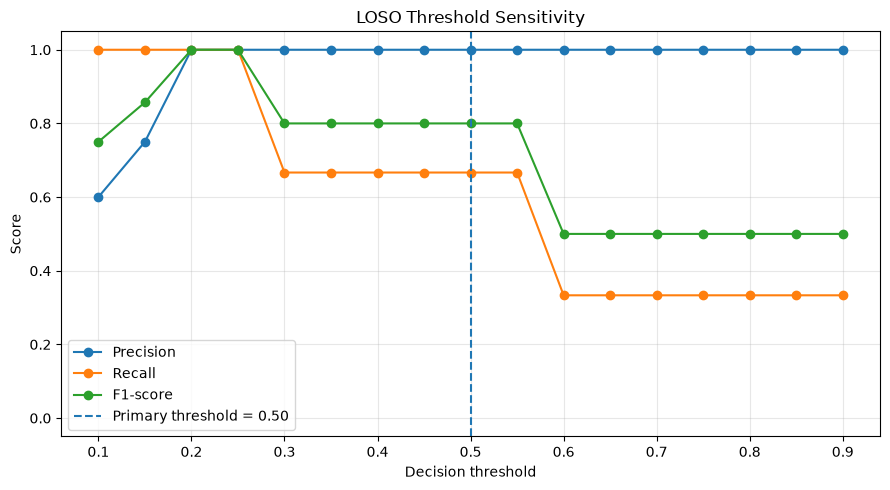


CELL 41 COMPLETE — THRESHOLD FIGURE SAVED

Figure:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_loso_threshold_sensitivity.png


In [54]:
# Cell 41 — Plot LOSO threshold sensitivity

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1"],
    marker="o",
    label="F1-score"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Primary threshold = 0.50"
)

plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("LOSO Threshold Sensitivity")
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

THRESHOLD_FIGURE = (
    REPORTS_DIR / "pics_loso_threshold_sensitivity.png"
)

plt.savefig(
    THRESHOLD_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("=" * 70)
print("CELL 41 COMPLETE — THRESHOLD FIGURE SAVED")
print("=" * 70)
print()
print("Figure:")
print(THRESHOLD_FIGURE)

In [57]:
# Cell 42 — Identify available trained model objects

print("=" * 70)
print("SEARCHING FOR TRAINED MODEL OBJECTS")
print("=" * 70)

candidate_models = []

# Make a fixed snapshot before iterating
global_items = list(globals().items())

for variable_name, variable_value in global_items:

    if variable_name.startswith("_"):
        continue

    if hasattr(variable_value, "coef_"):

        try:
            coefficient_shape = variable_value.coef_.shape
        except Exception:
            continue

        candidate_models.append(
            (
                variable_name,
                type(variable_value).__name__,
                coefficient_shape
            )
        )

print()
print("Fitted models with coefficient information:")

if len(candidate_models) == 0:

    print("No fitted coefficient-based model found.")

else:

    for name, model_type, coef_shape in candidate_models:

        print(
            f"Variable: {name} | "
            f"Type: {model_type} | "
            f"Coefficient shape: {coef_shape}"
        )

print()
print("=" * 70)
print("CELL 42 COMPLETE — MODEL OBJECTS IDENTIFIED")
print("=" * 70)

SEARCHING FOR TRAINED MODEL OBJECTS

Fitted models with coefficient information:
No fitted coefficient-based model found.

CELL 42 COMPLETE — MODEL OBJECTS IDENTIFIED


In [59]:
# Cell 43 — Fit explicit descriptive model for feature importance

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

print("=" * 70)
print("FITTING DESCRIPTIVE MODEL FOR FEATURE IMPORTANCE")
print("=" * 70)

# Rebuild the modeling matrix from the verified final dataset.
# This model is descriptive only and is NOT part of LOSO evaluation.

X_descriptive = final_feature_df[
    physiological_features
].copy()

y_descriptive = final_feature_df[
    "risk_label"
].to_numpy()

print()
print("Input matrix shape:", X_descriptive.shape)
print("Target shape:", y_descriptive.shape)

print()
print("Class distribution:")
print(
    final_feature_df["risk_label"]
    .value_counts()
    .sort_index()
)

# Standardization + balanced logistic regression
feature_importance_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "logistic",
            LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                random_state=42
            )
        )
    ]
)

feature_importance_model.fit(
    X_descriptive,
    y_descriptive
)

print()
print("Model fitted successfully.")

print()
print("=" * 70)
print("CELL 43 COMPLETE — DESCRIPTIVE MODEL READY")
print("=" * 70)

FITTING DESCRIPTIVE MODEL FOR FEATURE IMPORTANCE

Input matrix shape: (12, 20)
Target shape: (12,)

Class distribution:
risk_label
0    9
1    3
Name: count, dtype: int64

Model fitted successfully.

CELL 43 COMPLETE — DESCRIPTIVE MODEL READY


In [60]:
# Cell 44 — Rank physiological features by descriptive coefficient magnitude

print("=" * 70)
print("DESCRIPTIVE FEATURE IMPORTANCE")
print("=" * 70)

# Extract coefficients from the fitted logistic-regression step
logistic_step = feature_importance_model.named_steps["logistic"]

coefficients = logistic_step.coef_[0]

feature_importance_df = pd.DataFrame({
    "feature": physiological_features,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients)
})

# Rank by absolute coefficient magnitude
feature_importance_df = (
    feature_importance_df
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print()
print("Features ranked by absolute standardized coefficient:")
print()

display(feature_importance_df)

print()
print("=" * 70)
print("CELL 44 COMPLETE — FEATURE IMPORTANCE RANKED")
print("=" * 70)

DESCRIPTIVE FEATURE IMPORTANCE

Features ranked by absolute standardized coefficient:



,feature,coefficient,absolute_coefficient
0,r_peak_count,0.699660,0.699660
1,resp_peak_count,0.436675,0.436675
2,std_resp_interval,0.357061,0.357061
3,mean_resp_interval,0.352172,0.352172
4,min_hr,-0.348586,0.348586
5,std_rr,0.331529,0.331529
6,mean_resp_rate,-0.316650,0.316650
7,std_hr,0.297557,0.297557
8,sdnn,-0.265063,0.265063
9,mean_rr,0.161587,0.161587



CELL 44 COMPLETE — FEATURE IMPORTANCE RANKED


In [61]:
# Cell 45 — Save descriptive feature-importance ranking

FEATURE_IMPORTANCE_FILE = (
    REPORTS_DIR / "pics_descriptive_feature_importance.csv"
)

feature_importance_df.to_csv(
    FEATURE_IMPORTANCE_FILE,
    index=False
)

print("=" * 70)
print("DESCRIPTIVE FEATURE IMPORTANCE SAVED")
print("=" * 70)

print()
print("File:")
print(FEATURE_IMPORTANCE_FILE)

print()
print("Rows:", len(feature_importance_df))
print("Features:", len(physiological_features))

print()
print("=" * 70)
print("CELL 45 COMPLETE — FEATURE IMPORTANCE CHECKPOINT SAVED")
print("=" * 70)

DESCRIPTIVE FEATURE IMPORTANCE SAVED

File:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_descriptive_feature_importance.csv

Rows: 20
Features: 20

CELL 45 COMPLETE — FEATURE IMPORTANCE CHECKPOINT SAVED


PLOTTING DESCRIPTIVE FEATURE IMPORTANCE

Feature-importance plot generated.

CELL 46 COMPLETE — FEATURE IMPORTANCE PLOT READY


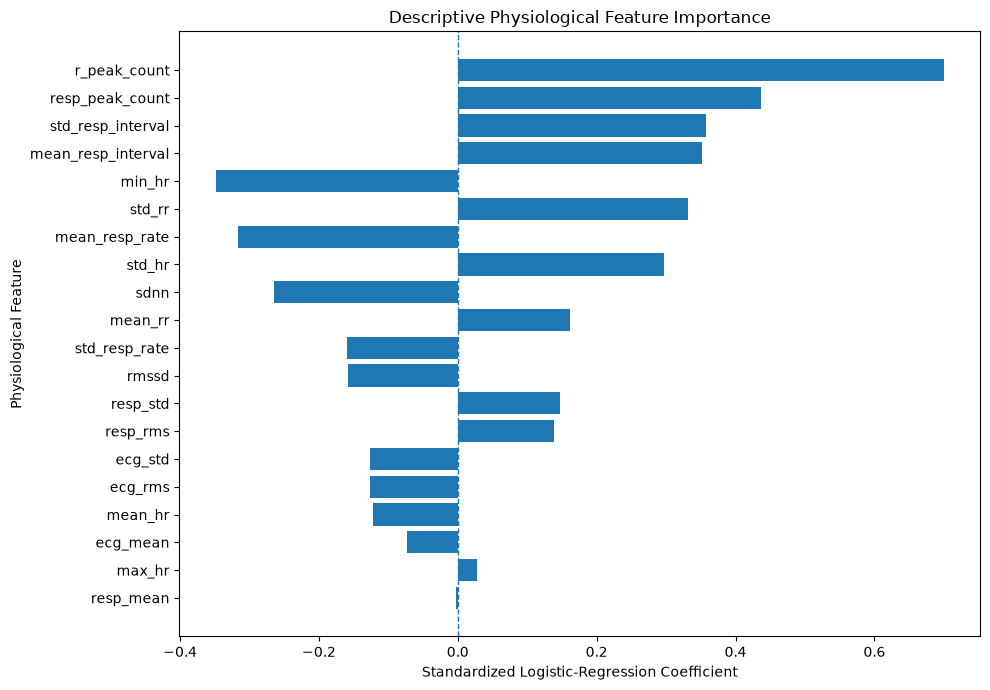

In [62]:
# Cell 46 — Plot descriptive feature importance

print("=" * 70)
print("PLOTTING DESCRIPTIVE FEATURE IMPORTANCE")
print("=" * 70)

plot_df = feature_importance_df.sort_values(
    "absolute_coefficient",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"],
    plot_df["coefficient"]
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Standardized Logistic-Regression Coefficient")
plt.ylabel("Physiological Feature")
plt.title(
    "Descriptive Physiological Feature Importance"
)

plt.tight_layout()

print()
print("Feature-importance plot generated.")

print()
print("=" * 70)
print("CELL 46 COMPLETE — FEATURE IMPORTANCE PLOT READY")
print("=" * 70)

plt.show()

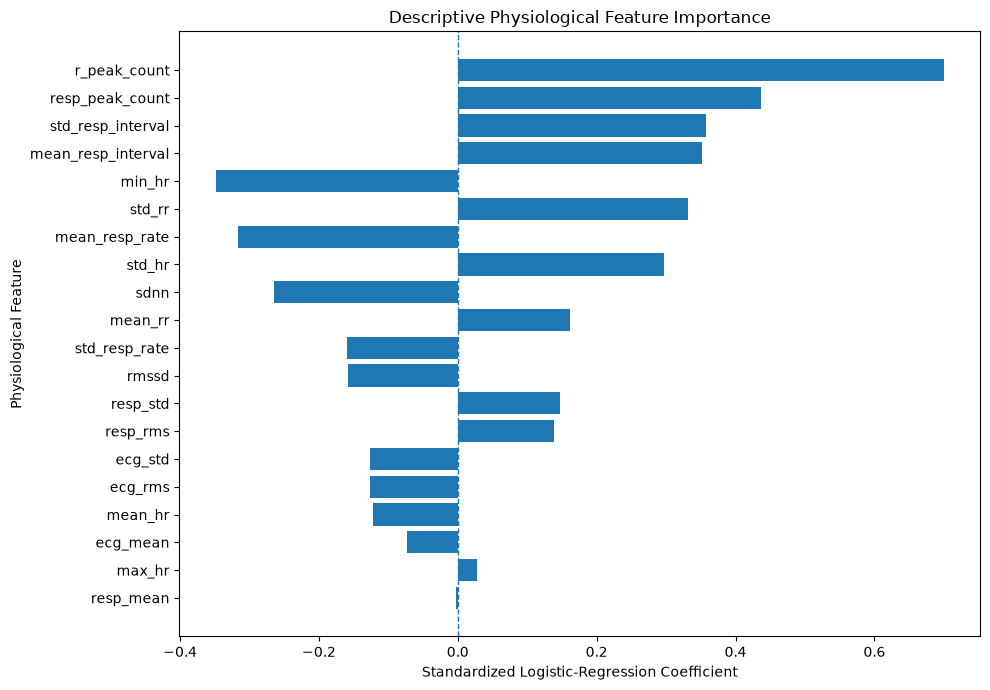


CELL 47 COMPLETE — FEATURE IMPORTANCE PLOT SAVED

File:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_descriptive_feature_importance.png


In [63]:
# Cell 47 — Save descriptive feature-importance plot

FEATURE_IMPORTANCE_PLOT = (
    REPORTS_DIR / "pics_descriptive_feature_importance.png"
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"],
    plot_df["coefficient"]
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Standardized Logistic-Regression Coefficient")
plt.ylabel("Physiological Feature")
plt.title(
    "Descriptive Physiological Feature Importance"
)

plt.tight_layout()

plt.savefig(
    FEATURE_IMPORTANCE_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("=" * 70)
print("CELL 47 COMPLETE — FEATURE IMPORTANCE PLOT SAVED")
print("=" * 70)

print()
print("File:")
print(FEATURE_IMPORTANCE_PLOT)

In [64]:
# Cell 48 — Fit baseline deployment model on the complete development dataset

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("=" * 70)
print("FITTING BASELINE DEPLOYMENT MODEL")
print("=" * 70)

# Use the verified complete dataset
X_deployment = final_feature_df[
    physiological_features
].copy()

y_deployment = final_feature_df[
    "risk_label"
].to_numpy()

print()
print("Deployment training matrix:", X_deployment.shape)
print("Deployment target shape:", y_deployment.shape)

print()
print("Class distribution:")
print(
    final_feature_df["risk_label"]
    .value_counts()
    .sort_index()
)

# Baseline model:
# Standardization -> balanced logistic regression
baseline_deployment_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "logistic",
            LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                random_state=42
            )
        )
    ]
)

baseline_deployment_model.fit(
    X_deployment,
    y_deployment
)

print()
print("Baseline deployment model fitted successfully.")

print()
print("=" * 70)
print("CELL 48 COMPLETE — BASELINE DEPLOYMENT MODEL READY")
print("=" * 70)

FITTING BASELINE DEPLOYMENT MODEL

Deployment training matrix: (12, 20)
Deployment target shape: (12,)

Class distribution:
risk_label
0    9
1    3
Name: count, dtype: int64

Baseline deployment model fitted successfully.

CELL 48 COMPLETE — BASELINE DEPLOYMENT MODEL READY


In [66]:
# Cell 49 — Generate deployment-model predictions and probabilities
# Corrected to use the actual metadata columns available in final_feature_df

print("=" * 70)
print("BASELINE DEPLOYMENT MODEL PREDICTIONS")
print("=" * 70)

# Generate probabilities from the fitted deployment model
deployment_probabilities = (
    baseline_deployment_model
    .predict_proba(X_deployment)[:, 1]
)

# Primary decision threshold
deployment_predictions = (
    deployment_probabilities >= 0.50
).astype(int)

# Start from the complete final feature dataframe
deployment_prediction_df = final_feature_df.copy()

# Add model outputs
deployment_prediction_df["predicted_probability"] = (
    deployment_probabilities
)

deployment_prediction_df["predicted_label"] = (
    deployment_predictions
)

print()
print("Final feature dataframe shape:")
print(final_feature_df.shape)

print()
print("Available columns:")
print(
    list(final_feature_df.columns)
)

print()
print("=" * 70)
print("PREDICTION DISTRIBUTION")
print("=" * 70)

print(
    pd.Series(
        deployment_predictions,
        name="predicted_label"
    ).value_counts().sort_index()
)

print()
print("=" * 70)
print("PREDICTIONS")
print("=" * 70)

display(
    deployment_prediction_df
)

print()
print("=" * 70)
print("CELL 49 COMPLETE — DEPLOYMENT PREDICTIONS GENERATED")
print("=" * 70)

BASELINE DEPLOYMENT MODEL PREDICTIONS

Final feature dataframe shape:
(12, 28)

Available columns:
['infant', 'event_number', 'event_time_s', 'window_start_s', 'window_end_s', 'window_duration_s', 'risk_label', 'window_type', 'ecg_mean', 'ecg_std', 'ecg_rms', 'r_peak_count', 'mean_rr', 'std_rr', 'mean_hr', 'min_hr', 'max_hr', 'std_hr', 'sdnn', 'rmssd', 'resp_mean', 'resp_std', 'resp_rms', 'resp_peak_count', 'mean_resp_interval', 'std_resp_interval', 'mean_resp_rate', 'std_resp_rate']

PREDICTION DISTRIBUTION
predicted_label
0    9
1    3
Name: count, dtype: int64

PREDICTIONS


,infant,event_number,event_time_s,window_start_s,window_end_s,window_duration_s,risk_label,window_type,ecg_mean,ecg_std,...,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate,predicted_probability,predicted_label
0,3,3.0,9427.30,9412.30,9427.30,15.0,1,precursor,0.000513,0.214855,...,0.050917,3.000542,3.000974,12,1.803636,0.820590,37.967655,11.223206,0.994872,1
1,9,1.0,6900.05,6885.05,6900.05,15.0,1,precursor,-0.008048,0.212087,...,-0.037453,0.881564,0.882359,10,2.480000,1.408198,29.411430,10.911885,0.980431,1
2,9,2.0,10072.60,10057.60,10072.60,15.0,1,precursor,0.001117,0.213129,...,-0.114755,0.768925,0.777441,15,1.537143,0.380215,41.329361,9.427021,0.947925,1
3,3,NaN,NaN,13620.00,13635.00,15.0,0,control,-0.000648,0.218571,...,-0.112603,1.013942,1.020175,9,1.687500,0.352978,37.971747,11.898955,0.168578,0
4,3,NaN,NaN,102450.00,102465.00,15.0,0,control,0.002089,0.234485,...,0.105733,0.403634,0.417253,11,1.402000,0.281489,44.718934,9.892682,0.112304,0
5,3,NaN,NaN,121410.00,121425.00,15.0,0,control,-0.000247,0.232966,...,0.230981,0.530434,0.578543,13,1.133333,0.261449,55.435149,11.170463,0.112946,0
6,9,NaN,NaN,21120.00,21135.00,15.0,0,control,-0.001007,0.236986,...,-0.083044,0.746492,0.751097,12,1.298182,0.244719,48.135729,10.452991,0.123672,0
7,9,NaN,NaN,23235.00,23250.00,15.0,0,control,0.003149,0.416142,...,0.484749,2.209372,2.261925,12,1.258182,0.461732,53.282334,15.928698,0.063684,0
8,9,NaN,NaN,50460.00,50475.00,15.0,0,control,-0.000670,0.257788,...,-0.493255,1.327113,1.415814,10,1.506667,0.301699,41.514336,8.760226,0.141894,0
9,9,NaN,NaN,132045.00,132060.00,15.0,0,control,-0.002903,0.240194,...,0.187453,0.826761,0.847745,11,1.420000,0.487688,47.288620,15.441402,0.151988,0



CELL 49 COMPLETE — DEPLOYMENT PREDICTIONS GENERATED


In [67]:
# Cell 50 — Save baseline deployment predictions

DEPLOYMENT_PREDICTIONS_FILE = (
    REPORTS_DIR / "pics_baseline_deployment_predictions.csv"
)

deployment_prediction_df.to_csv(
    DEPLOYMENT_PREDICTIONS_FILE,
    index=False
)

print("=" * 70)
print("BASELINE DEPLOYMENT PREDICTIONS SAVED")
print("=" * 70)

print()
print("File:")
print(DEPLOYMENT_PREDICTIONS_FILE)

print()
print("Dataset shape:")
print(deployment_prediction_df.shape)

print()
print("Saved prediction columns:")
print(
    [
        "infant",
        "event_number",
        "event_time_s",
        "window_start_s",
        "window_end_s",
        "risk_label",
        "window_type",
        "predicted_probability",
        "predicted_label"
    ]
)

print()
print("=" * 70)
print("CELL 50 COMPLETE — DEPLOYMENT PREDICTIONS CHECKPOINT SAVED")
print("=" * 70)

BASELINE DEPLOYMENT PREDICTIONS SAVED

File:
C:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_baseline_deployment_predictions.csv

Dataset shape:
(12, 30)

Saved prediction columns:
['infant', 'event_number', 'event_time_s', 'window_start_s', 'window_end_s', 'risk_label', 'window_type', 'predicted_probability', 'predicted_label']

CELL 50 COMPLETE — DEPLOYMENT PREDICTIONS CHECKPOINT SAVED


In [1]:
# Cell 51 — Verify baseline deployment model for edge deployment

print("=" * 70)
print("VERIFYING BASELINE DEPLOYMENT MODEL")
print("=" * 70)

print()
print("Model object:")
print(type(baseline_deployment_model))

print()
print("Model steps:")
print(baseline_deployment_model.named_steps)

print()
print("Expected physiological features:")
print(len(physiological_features))

print()
print(physiological_features)

print()
print("Deployment matrix shape:")
print(X_deployment.shape)

print()
print("Deployment target shape:")
print(y_deployment.shape)

print()
print("Decision threshold:")
print("0.50")

print()
print("=" * 70)
print("CELL 51 COMPLETE — DEPLOYMENT MODEL VERIFIED")
print("=" * 70)

VERIFYING BASELINE DEPLOYMENT MODEL

Model object:


NameError: name 'baseline_deployment_model' is not defined